# 资产定价检验：预测 Expected Shortfall 与未来股票收益

本 notebook 只使用前一步冻结的样本外预测，不使用资产定价结果选择模型或修改 ES 定义。

主要检验：

1. 五个模型的 5% loss-ES 单变量组合排序；
2. High ES minus Low ES 的均值、Newey–West $t$ 值和因子调整 alpha；
3. Fama–MacBeth 横截面回归；
4. Structured K3 的 adverse contribution 与 severity 定价；
5. severity premium 是否随 macro-conditioned adverse weight 变化；
6. 1%/10% ES、五组、breakpoints 和 microcap 的稳健性。

时间约定始终为：$widehat{ES}_{i,t}\rightarrow R_{i,t+1}$。`mthcaldt` 是信号形成月，`target_ret_final` 是下一月收益。

In [1]:
# ==========================================
# 1. 设置路径、模型版本和主要参数
# ==========================================
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/pricing-matplotlib")

from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display


# warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# 该时间戳必须对应已经冻结的模型预测版本
model_timestamp = "20260831_1753"

project_root = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")
forecast_dir = Path("/Users/jianbinchen/Downloads/results")
comparison_dir = project_root / "output/model_comparison"
result_dir = project_root / "output/pricing_test"
figure_dir = project_root / "overleaf/fig"
result_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

WRDS_db_path = Path("/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite")

model_order = ["rolling_normal", "linear_quantile", "fused_normal_k1", "fused_normal_k3", "structured_normal_k3"]
model_labels = {
    "rolling_normal": "Rolling Normal", 
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1", 
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
}
model_files = {
    "rolling_normal": forecast_dir / f"rolling_normal_forecasts_{model_timestamp}.parquet",
    "linear_quantile": forecast_dir / f"linear_quantile_forecasts_{model_timestamp}.parquet",
    "fused_normal_k1": forecast_dir / f"fused_k1_forecasts_{model_timestamp}.parquet",
    "fused_normal_k3": forecast_dir / f"fused_k3_forecasts_{model_timestamp}.parquet",
    "structured_normal_k3": forecast_dir / f"structured_forecasts_{model_timestamp}.parquet",
}

industry_type = "ffi12"  # 'ffi12' 或 'ffi49'
PRIMARY_ALPHA = 0.05
PRIMARY_GROUPS = 10
NW_LAGS = 12

model_colors = {
    "rolling_normal": "#4C78A8", 
    "linear_quantile": "#F2A541", 
    "fused_normal_k1": "#8C8C8C",
    "fused_normal_k3": "#B279A2", 
    "structured_normal_k3": "#2F6B4F",
}
signal_colors = {
    "Total ES (5%)": "#2F6B4F", 
    "Adverse contribution": "#D98C3F", 
    "Adverse severity": "#4C78A8",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

print("Model forecast version:", model_timestamp)
print("Pricing output directory:", result_dir)
print("Figure output directory:", figure_dir)

Model forecast version: 20260831_1753
Pricing output directory: /Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/output/pricing_test
Figure output directory: /Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig


## 2. 构建资产定价样本

- `mthcap` 使用信号月末市值，因此 value weights 不使用未来信息；
- `crsp_msenames` 按信号日期识别 common shares 和 NYSE 股票；
- NYSE 股票只用于形成 breakpoints，全部合格股票随后参与组合；
- FF factors 与下一月组合收益对齐。

In [2]:
# ==========================================
# 2.1 读取 Structured components、公司特征和 WRDS 数据
# ==========================================
structured_components = pd.read_parquet(comparison_dir / f"structured_component_rows_{model_timestamp}.parquet")
structured_components["mthcaldt"] = pd.to_datetime(structured_components["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([structured_components.head(), structured_components.tail()]))

micro_data = pd.read_parquet(project_root / "data/micro_data.parquet")
micro_data["mthcaldt"] = pd.to_datetime(micro_data["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([micro_data.head(), micro_data.tail()]))

with sqlite3.connect(WRDS_db_path) as conn:
    crsp_names = pd.read_sql_query(
        "SELECT permno, namedt, nameendt, shrcd, exchcd FROM crsp_msenames", conn
    )
    ff3 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, umd, rf FROM ff_factors_monthly", conn
    )
    ff5 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, rmw, cma, umd, rf FROM ff_fivefactors_monthly", conn
    )

structured_components["permno"] = structured_components["permno"].astype("Int64")
micro_data["permno"] = micro_data["permno"].astype("Int64")

ff3["return_date"] = pd.to_datetime(dict(year=ff3["year"].astype(int), month=ff3["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff5["return_date"] = pd.to_datetime(dict(year=ff5["year"].astype(int), month=ff5["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff3 = ff3.rename(columns={c: f"{c}_ff3" for c in ["mktrf", "smb", "hml", "umd", "rf"]})
ff5 = ff5.rename(columns={c: f"{c}_ff5" for c in ["mktrf", "smb", "hml", "rmw", "cma", "umd", "rf"]})
factor_data = ff3.drop(columns=["year", "month"]).merge(
    ff5.drop(columns=["year", "month"]), on="return_date", validate="one_to_one"
)
display(pd.concat([factor_data.head(), factor_data.tail()]))

,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable
0,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.137231,0.180256,2.035929,0.596651,True,0.180256,0.596651,-0.002109,0.093437,0.883902,0.178984,0.158204,0.365745,0.021116,0.065137,0.055074,0.158660,0.008738,0.037604,0.111644,0.178093,0.061024,0.218167,0.013313,0.288368,0.675133
1,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.267241,0.341703,2.035929,0.596651,True,0.341703,0.596651,-0.040351,0.161778,0.959248,0.340634,0.326752,0.365745,0.040656,0.100028,0.007619,0.295017,0.002248,0.037604,0.216377,0.283573,0.033133,0.383401,0.012703,0.602306,0.826432
2,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.129451,0.168215,2.035929,0.596651,True,0.168215,0.596651,-0.009281,0.082944,0.879405,0.166480,0.146404,0.365745,0.017426,0.059464,0.049416,0.148802,0.007353,0.037604,0.077114,0.157361,0.071180,0.203129,0.014459,0.370077,0.501789
3,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.434075,0.541191,2.035929,0.596651,True,0.541191,0.596651,-0.105707,0.236118,0.980404,0.541634,0.531020,0.365745,0.026387,0.152415,0.009211,0.476997,0.004394,0.037604,0.332658,0.348088,0.010385,0.556329,0.005777,0.664710,1.139840
4,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.167657,0.219821,2.035929,0.596651,True,0.219821,0.596651,-0.005962,0.113731,0.925426,0.218909,0.202584,0.365745,0.028451,0.073706,0.028521,0.190431,0.005431,0.037604,0.149378,0.205269,0.046053,0.256355,0.011806,0.359104,0.784117
480441,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.151824,0.216612,1.350445,0.853860,True,0.216612,0.853860,-0.010818,0.082483,0.745887,0.185566,0.138412,0.053825,0.047448,0.271740,0.249405,0.310153,0.077354,0.092315,0.111881,0.094157,0.004707,0.179865,0.000847,0.290160,0.316845
480442,93397,2024-12-31,-0.057236,structured_normal_k3,17,-0.128393,0.184750,1.350445,0.853860,True,0.184750,0.853860,-0.006005,0.071143,0.729013,0.157394,0.114743,0.053825,0.017775,0.217901,0.270389,0.258591,0.069920,0.092315,0.099487,0.066810,0.000598,0.145533,0.000087,0.146710,0.507026
480443,93426,2024-12-31,-0.007243,structured_normal_k3,17,-0.152765,0.217655,1.350445,0.853860,True,0.217655,0.853860,-0.012109,0.082343,0.748020,0.186465,0.139479,0.053825,0.049892,0.274556,0.247830,0.312427,0.077429,0.092315,0.109296,0.092240,0.004151,0.179950,0.000747,0.305901,0.290055
480444,93434,2024-12-31,0.147685,structured_normal_k3,17,-0.322519,0.425872,1.350445,0.853860,True,0.425872,0.853860,-0.041375,0.165507,0.763167,0.390465,0.297990,0.053825,0.099118,0.150708,0.002770,0.367437,0.001018,0.092315,0.180663,0.440702,0.234063,0.542010,0.126864,0.887615,0.247600
480445,93436,2024-12-31,0.001882,structured_normal_k3,17,-0.126070,0.174346,1.350445,0.853860,True,0.174346,0.853860,-0.000838,0.073671,0.761254,0.156303,0.118986,0.053825,0.015439,0.184367,0.238315,0.232035,0.055297,0.092315,0.132284,0.073832,0.000431,0.144634,0.000062,0.115941,0.832041


,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,siccd,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450,4920,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450,4920,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450,4920,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464,4920,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464,4920,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
1305248,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000,3711,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305249,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060,3711,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305250,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060,3711,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305251,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517,3711,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305252,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517,3711,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31


,mktrf_ff3,smb_ff3,hml_ff3,umd_ff3,rf_ff3,return_date,mktrf_ff5,smb_ff5,hml_ff5,rmw_ff5,cma_ff5,umd_ff5,rf_ff5
0,-0.0039,-0.0057,-0.0081,0.0101,0.0027,1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1,0.0508,-0.0095,0.0170,0.0100,0.0025,1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
2,-0.0157,-0.0025,0.0000,0.0012,0.0027,1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
3,0.0254,-0.0057,-0.0004,0.0313,0.0029,1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
4,-0.0086,-0.0116,0.0173,-0.0078,0.0027,1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
744,0.0198,0.0026,-0.0127,-0.0097,0.0034,2025-07-31,0.0198,-0.0015,-0.0127,-0.0029,-0.0207,-0.0097,0.0034
745,0.0184,0.0387,0.0442,-0.0354,0.0038,2025-08-31,0.0185,0.0488,0.0442,-0.0067,0.0208,-0.0354,0.0038
746,0.0339,-0.0185,-0.0105,0.0463,0.0033,2025-09-30,0.0339,-0.0218,-0.0105,-0.0203,-0.0222,0.0463,0.0033
747,0.0196,-0.0055,-0.0309,0.0028,0.0037,2025-10-31,0.0196,-0.0131,-0.0309,-0.0522,-0.0403,0.0028,0.0037
748,-0.0013,0.0038,0.0376,-0.0180,0.0030,2025-11-30,-0.0013,0.0147,0.0376,0.0143,0.0068,-0.0180,0.0030


In [3]:
# =========================================================
# 核心修复：强制对齐“日历月网格” (Resampling to Continuous Grid)
# =========================================================
print(" -> Reindexing panel data to a continuous monthly grid...")

# 2. 将日期设置为 Index，为 Pandas 的重采样做准备
micro_data = micro_data.set_index('mthcaldt')

# 3. ★ 核心魔法：按 permno 分组，按月 ('ME' 或 'M') 重新采样
# 只要两个日期之间有断层，Pandas 就会自动插入缺失的月份，并将那一行的值设为 NaN
micro_data = micro_data.groupby('permno').resample('ME').asfreq().drop(columns=['permno']).reset_index()
print(" -> Reindexing completed. New shape:", micro_data.shape)
# =========================================================
# 数据预处理
# =========================================================
micro_cols = ['mthret', 'mthprc', 'bm', 'evm', 'ps', 'pcf', 'opmad', 'cfm', 'roe', 'gprof', 'debt_at', 'short_debt', 'cash_ratio', 'curr_ratio', 'at_turn', 'rd_sale', 'accrual']

micro_data = micro_data.sort_values(['permno', 'mthcaldt']).reset_index(drop=True)
# 1. 计算 t+1 收益率
# micro_data['target_ret_final'] = micro_data.groupby('permno')['mthret'].shift(-1)

# 2. 计算过去 12 个月动量（跳过近 1 月，滚动 11 月）
micro_data['log_ret'] = np.log1p(micro_data['mthret'])
micro_data['MOM12m'] = micro_data.groupby('permno')['log_ret'].transform(
    lambda x: x.shift(1).rolling(window=11, min_periods=6).sum()
)
micro_data['MOM12m'] = np.exp(micro_data['MOM12m']) - 1
micro_data = micro_data.drop(columns=['log_ret'])

# 3. 在完整微观时间序列上计算 12 个月滚动均值和标准差
micro_data['mu_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).mean()
)
micro_data['sigma_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).std()
)

# # 这里只使用 t 时点可以观察的信息筛选
# formation_required = ["mthret", "mthprc", "mthcap", "shrout", "gvkey"]

# micro_data = micro_data[
#     micro_data[formation_required].notna().all(axis=1)
# ].copy()

micro_data = micro_data[micro_data[[ 'mthret', 'shrout', 'gvkey']].notna().all(axis=1)]

print(" -> After filtering, new shape:", micro_data.shape)

micro_data['turnover'] = micro_data['mthvol'] / (micro_data['shrout'] * 1000)

# 对mthcap和mthvol取log
micro_data['mthcap_log'] = np.log(micro_data['mthcap'])

derived_micro_cols = ['MOM12m', 'mu_bench', 'sigma_bench', 'turnover', 'mthcap_log']
micro_cols = micro_cols + derived_micro_cols

# 剔除价格低于 5 美元的股票
micro_data = micro_data[micro_data['mthprc'] >= 5].copy()

# 剔除金融行业 (SIC 代码 6000 至 6999) 
micro_data['siccd']=micro_data['siccd'].astype('Int64')
print(f"Total rows before removing financial sector: {len(micro_data)}")
micro_data=micro_data[(micro_data['siccd'] < 6000) | (micro_data['siccd'] > 6999)]
print(f"Total rows after removing financial sector: {len(micro_data)}")
micro_data=micro_data.drop(columns=['siccd'])
print(f"Total rows after dropping siccd column: {len(micro_data)}")
print(f"Total duplicates found after merging: {micro_data.duplicated(subset=['permno', 'mthcaldt'], keep=False).sum()}")
display(pd.concat([micro_data.head(), micro_data.tail()]))


 -> Reindexing panel data to a continuous monthly grid...
 -> Reindexing completed. New shape: (1320379, 29)


/Users/jianbinchen/miniconda3/envs/research/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


 -> After filtering, new shape: (1257225, 32)
Total rows before removing financial sector: 954776
Total rows after removing financial sector: 729677
Total rows after dropping siccd column: 729677
Total duplicates found after merging: 0


,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450.0,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.013260,9.943909
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450.0,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.016462,9.898789
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450.0,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.009051,9.914057
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464.0,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.029351,9.888983
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464.0,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.010690,9.900633
1320374,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000.0,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,-0.144312,0.014849,0.153502,0.500220,20.547778
1320375,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060.0,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,0.302679,0.027542,0.140071,0.592335,20.502661
1320376,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060.0,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.040696,0.043050,0.167882,0.648627,20.825808
1320377,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517.0,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.389088,0.054301,0.171772,0.589036,20.984828
1320378,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517.0,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,1.156231,0.074980,0.145178,0.467122,20.986709


In [4]:
crsp_names["permno"] = crsp_names["permno"].astype("Int64")
crsp_names["namedt"] = pd.to_datetime(crsp_names["namedt"])
crsp_names["nameendt"] = pd.to_datetime(crsp_names["nameendt"])
crsp_names["nameendt"] = crsp_names["nameendt"].fillna(pd.Timestamp("2262-04-11"))

pricing_base = structured_components.merge(
    micro_data,
    on=["permno", "mthcaldt"],
    how="left",
    validate="one_to_one",
)

pricing_base = pricing_base.merge(
    crsp_names,
    on="permno",
    how="left",
)
print(f"Total rows after merging: {len(pricing_base)}")
valid_name_period = (
    pricing_base["mthcaldt"].ge(pricing_base["namedt"])
    & pricing_base["mthcaldt"].le(pricing_base["nameendt"])
)

pricing_base = pricing_base.loc[valid_name_period].copy()
print(f"Total rows after filtering by valid name period: {valid_name_period.sum()}")

# 只保留普通股和三大交易所
pricing_base = pricing_base[
    pricing_base["shrcd"].isin([10, 11])
    & pricing_base["exchcd"].isin([1, 2, 3])
].copy()
print(f"Total rows after filtering by shrcd and exchcd: {len(pricing_base)}")

pricing_base["is_nyse"] = pricing_base["exchcd"].eq(1)

if pricing_base.duplicated(["permno", "mthcaldt"]).any():
    raise ValueError("CRSP name-history matching produced duplicate firm-months")

pricing_base["return_date"] = pricing_base["mthcaldt"] + pd.offsets.MonthEnd(1)
display(pd.concat([pricing_base.head(), pricing_base.tail()]))

Total rows after merging: 2679379
Total rows after filtering by valid name period: 480446
Total rows after filtering by shrcd and exchcd: 480429


,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log,namedt,nameendt,shrcd,exchcd,is_nyse,return_date
4,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.137231,0.180256,2.035929,0.596651,True,0.180256,0.596651,-0.002109,0.093437,0.883902,0.178984,0.158204,0.365745,0.021116,0.065137,0.055074,0.158660,0.008738,0.037604,0.111644,0.178093,0.061024,0.218167,0.013313,0.288368,0.675133,0.023279,11.3584,3.360951e+04,2.565300e+04,2959.0,12994,2007-01-31,0.782398,7.783603,0.461289,5.069307,0.072001,0.076558,0.102871,0.110003,0.370948,0.214735,0.060371,1.311260,1.183344,0.000000,-0.066651,8.0,31.0,1986-01-09,2017-08-31,0.203138,0.020930,0.088735,0.008669,10.422564,2004-12-27,2008-02-04,11,3,False,2007-02-28
11,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.267241,0.341703,2.035929,0.596651,True,0.341703,0.596651,-0.040351,0.161778,0.959248,0.340634,0.326752,0.365745,0.040656,0.100028,0.007619,0.295017,0.002248,0.037604,0.216377,0.283573,0.033133,0.383401,0.012703,0.602306,0.826432,-0.125305,46.6300,3.700557e+05,1.080610e+06,7936.0,11903,2007-01-31,0.143568,7.057821,0.461353,6.187187,0.086494,0.071010,1.073700,0.532784,0.585123,0.060535,0.016326,2.003190,2.477928,0.001496,-0.065007,3.0,15.0,1986-01-30,2017-01-31,1.050385,0.057992,0.140733,0.136166,12.821409,2004-06-10,2009-01-29,11,3,False,2007-02-28
15,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.129451,0.168215,2.035929,0.596651,True,0.168215,0.596651,-0.009281,0.082944,0.879405,0.166480,0.146404,0.365745,0.017426,0.059464,0.049416,0.148802,0.007353,0.037604,0.077114,0.157361,0.071180,0.203129,0.014459,0.370077,0.501789,-0.002899,41.2800,7.653725e+05,1.216924e+06,18541.0,12825,2007-01-31,0.489391,8.145375,1.484563,13.905198,0.089849,0.105001,0.110334,0.577084,0.000000,NaN,1.296705,2.914993,1.592100,0.001084,-0.078904,1.0,2.0,1986-02-04,2099-12-31,0.379742,0.029112,0.069789,0.065634,13.548118,2004-06-10,2019-08-04,11,3,False,2007-02-28
20,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.434075,0.541191,2.035929,0.596651,True,0.541191,0.596651,-0.105707,0.236118,0.980404,0.541634,0.531020,0.365745,0.026387,0.152415,0.009211,0.476997,0.004394,0.037604,0.332658,0.348088,0.010385,0.556329,0.005777,0.664710,1.139840,-0.296482,16.8000,7.772520e+05,2.512802e+07,46265.0,12945,2007-01-31,0.542692,8.824937,0.532161,9.355014,0.054953,0.084790,0.244115,0.227097,0.033252,0.037411,0.680604,2.253812,2.083638,0.000000,0.024889,6.0,37.0,1986-02-05,2099-12-31,-0.156482,-0.027890,0.172200,0.543132,13.563520,2004-06-10,2019-09-11,11,3,False,2007-02-28
25,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.167657,0.219821,2.035929,0.596651,True,0.219821,0.596651,-0.005962,0.113731,0.925426,0.218909,0.202584,0.365745,0.028451,0.073706,0.028521,0.190431,0.005431,0.037604,0.149378,0.205269,0.046053,0.256355,0.011806,0.359104,0.784117,-0.085034,13.4500,8.212570e+04,3.810460e+05,6106.0,11976,2007-01-31,0.165279,11.203933,2.667443,16.654200,0.226177,0.172127,0.288203,0.671710,0.000000,NaN,0.447463,3.093992,1.750121,0.000000,-0.030665,1.0,2.0,1986-02-11,2099-12-31,0.079582,0.001647,0.076834,0.062405,11.316006,2004-06-10,2015-03-01,11,3,False,2007-02-28
2679368,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.151824,0.216612,1.350445,0.853860,True,0.216612,0.853860,-0.010818,0.082483,0.745887,0.185566,0.138412,0.053825,0.047448,0.271740,0.

## 3. 通用统计与组合函数

所有月度均值、H–L returns、Fama–MacBeth slopes 和 factor alphas 使用 12 阶 Newey–West 标准误。组合形成不使用下一月收益。

In [5]:
# ==========================================
# 3.1 通用统计函数
# ==========================================
def nw_mean(values, lags=NW_LAGS):
    # values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    values = pd.Series(values).to_numpy(dtype=float)
    fit = sm.OLS(values, np.ones((len(values), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": min(lags, len(values) - 1)}
    )
    mean, se = float(fit.params[0]), float(fit.bse[0])
    return {
        "mean_monthly": mean, "nw_se": se, "nw_t": float(fit.tvalues[0]),
        "p_value": float(fit.pvalues[0]), "ci_95_low": mean - 1.96 * se,
        "ci_95_high": mean + 1.96 * se, "months": len(values),
    }

def alpha_suffix(alpha):
    return f"{alpha * 100:g}".replace(".", "_")

def save_figure(fig, name):
    path = figure_dir / f"{name}_{model_timestamp}.pdf"
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    return path

control_cols = ["mthcap_log", "bm"]
base_model_cols = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse"] + control_cols

def load_model_panel(model_id, alpha=PRIMARY_ALPHA):
    es_col = f"es_{alpha_suffix(alpha)}"
    signal = pd.read_parquet(model_files[model_id], columns=["permno", "mthcaldt", es_col])
    signal["permno"] = signal["permno"].astype("Int64")
    signal["mthcaldt"] = pd.to_datetime(signal["mthcaldt"]) + pd.offsets.MonthEnd(0)
    panel = pricing_base[base_model_cols].merge(signal, on=["permno", "mthcaldt"], validate="one_to_one")
    return panel.rename(columns={es_col: "signal"})

In [6]:
# ==========================================
# 下载NYSE breakpoints, 只用于剔除末尾20%股票
# ==========================================
import pandas_datareader.data as web
# 获取 NYSE 市值 (ME) 断点数据
# 数据集名称为 'ME_Breakpoints'
me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')
# # famafrench 接口会返回一个字典，主数据集通常在索引 0 的位置
me_breakpoints = me_breakpoints[0]
me_breakpoints = me_breakpoints.rename(columns={(15, 20): "ff_nyse_me_p20"})

# 2. 如果 index 是 Period 类型，直接用 to_timestamp() 转换到当月末
me_breakpoints.index = me_breakpoints.index.to_timestamp(how="end").normalize()

# 3. 将 index 命名为 mthcaldt
me_breakpoints.index.name = "mthcaldt"
me_breakpoints[["ff_nyse_me_p20"]]=me_breakpoints[["ff_nyse_me_p20"]]*1000
me_breakpoints=me_breakpoints[["ff_nyse_me_p20"]].reset_index()

# 4. 查看结果
display(pd.concat([me_breakpoints.head(), me_breakpoints.tail()]))

/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_15335/3118671481.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')


,mthcaldt,ff_nyse_me_p20
0,1990-01-31,97240.0
1,1990-02-28,100360.0
2,1990-03-31,103910.0
3,1990-04-30,95870.0
4,1990-05-31,101230.0
433,2026-02-28,1051360.0
434,2026-03-31,1026340.0
435,2026-04-30,1120980.0
436,2026-05-31,1147020.0
437,2026-06-30,1231740.0


In [7]:
def assign_signal_groups(
    panel,
    signal_col,
    n_groups=10,
    breakpoint_universe="NYSE",
    me_breakpoints_df=None,
    exclude_microcaps=False,
):
    required = [
        "permno",
        "mthcaldt",
        "return_date",
        "target_ret_final",
        "mthcap",
        "mthcap_log",
        "bm",
        "is_nyse",
        signal_col,
    ]

    work = (
        panel[required]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    # # 注意：这里不要求 target_ret_final 非缺失
    # work = work.dropna(
    #     subset=[
    #         "permno",
    #         "mthcaldt",
    #         "mthcap",
    #         "is_nyse",
    #         signal_col,
    #     ]
    # ).copy()

    work = work[work["mthcap"] > 0].reset_index(drop=True)

    # 使用 FF 官方市值断点排除 microcaps
    if exclude_microcaps:
        work = work.merge(
            me_breakpoints_df[["mthcaldt", "ff_nyse_me_p20"]],
            on="mthcaldt",
            how="left",
            validate="many_to_one",
        )

        work = work[work["mthcap"] >= work["ff_nyse_me_p20"]].drop(columns="ff_nyse_me_p20")
        work = work.reset_index(drop=True)

    portfolio = np.full(len(work), -1, dtype=np.int16)
    probabilities = np.arange(1, n_groups) / n_groups

    for positions in work.groupby("mthcaldt", sort=False).indices.values():

        month = work.iloc[positions]

        if breakpoint_universe.lower() == "nyse":
            reference = month.loc[month["is_nyse"], signal_col]
        elif breakpoint_universe.lower() == "all":
            reference = month[signal_col]
        else:
            raise ValueError("breakpoint_universe must be 'NYSE' or 'All'")

        reference = reference.dropna().to_numpy(dtype=float)

        breaks = np.quantile(reference, probabilities)# breaks：代码的执行结果。它返回的是跟 probabilities 对应的具体数值（切分点）。

        portfolio[positions] = (
            np.searchsorted(
                breaks,
                month[signal_col].to_numpy(dtype=float),
                side="right",
            )
            + 1
        )

    work["portfolio"] = portfolio
    return work

In [8]:
def sort_portfolios(
    panel,
    signal_col,
    n_groups=10,
    me_breakpoints_df=me_breakpoints,
    exclude_microcaps=False,
    breakpoint_universe="NYSE",
):
    work = assign_signal_groups(
        panel=panel,
        signal_col=signal_col,
        n_groups=n_groups,
        breakpoint_universe=breakpoint_universe,
        me_breakpoints_df=me_breakpoints_df,
        exclude_microcaps=exclude_microcaps,
    )

    # 分组完成后，才处理下一月收益缺失
    realized = work.dropna(
        subset=["target_ret_final"]
    ).copy()

    realized["vw_numerator"] = realized["target_ret_final"] * realized["mthcap"]

    returns = (
        realized.groupby(
            [
                "mthcaldt",
                "return_date",
                "portfolio",
            ],
            as_index=False,
        )
        .agg(
            n_firms=("permno", "size"),
            mean_signal=(signal_col, "mean"),
            ew_return=("target_ret_final", "mean"),
            vw_numerator=("vw_numerator", "sum"),
            market_cap=("mthcap", "sum"),
        )
    )

    returns["vw_return"] = (
        returns["vw_numerator"] / returns["market_cap"]
    )

    return returns.drop(columns="vw_numerator")

In [9]:
# ==========================================
# 3.2 NYSE breakpoints、EW/VW portfolios 与 H-L
# ==========================================

# def sort_portfolios(panel, signal_col, n_groups=10, me_breakpoints_df=me_breakpoints, exclude_microcaps=False):
#   # 1. 清洗面板数据
#     cols = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap",  signal_col]
#     work = panel[cols].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

#     # 2. 清洗外部断点数据
#     bp_df = me_breakpoints_df.copy()

#     # 3. 剔除微盘股（如果开启）
#     if exclude_microcaps:
#         work = work.merge(bp_df[["mthcaldt", "20th_percentile"]], on="mthcaldt", how="left")
#         work = work[work["mthcap"] >= work["20th_percentile"]].drop(columns=["20th_percentile"])
#         work = work.reset_index(drop=True)

#     portfolio = np.empty(len(work), dtype=np.int8)
#     for positions in work.groupby("mthcaldt", sort=False).indices.values():
#         month = work.iloc[positions]
#         reference = month[signal_col]
#         breaks = np.quantile(reference, np.arange(1, n_groups) / n_groups)
#         portfolio[positions] = np.searchsorted(breaks, month[signal_col].to_numpy(), side="right") + 1

#     work["portfolio"] = portfolio

#     work["vw_numerator"] = work["target_ret_final"] * work["mthcap"]

#     returns = work.groupby(["mthcaldt", "return_date", "portfolio"], as_index=False).agg(
#         n_firms=("permno", "size"),
#         mean_signal=(signal_col, "mean"),
#         ew_return=("target_ret_final", "mean"),
#         vw_numerator=("vw_numerator", "sum"),
#         market_cap=("mthcap", "sum"),
#     )
#     returns["vw_return"] = returns["vw_numerator"] / returns["market_cap"]

#     return returns.drop(columns=["vw_numerator"])


def build_hml(portfolios, metadata):
    parts = []
    high, low = portfolios["portfolio"].max(), portfolios["portfolio"].min()
    for weighting in ["ew", "vw"]:
        wide = portfolios.pivot(index=["mthcaldt", "return_date"], columns="portfolio", values=f"{weighting}_return")
        result = (wide[high] - wide[low]).rename("hml_return").reset_index()
        result["weighting"] = weighting.upper()
        for key, value in metadata.items():
            result[key] = value
        parts.append(result)
    return pd.concat(parts, ignore_index=True)


def summarize_hml(hml):
    group_cols = ["model_id", "model_label", "signal_name", "weighting", "n_groups",  "exclude_microcaps", "breakpoint_universe",]
    rows = []
    for keys, group in hml.groupby(group_cols, dropna=False):
        stats = nw_mean(group["hml_return"])
        row = dict(zip(group_cols, keys))
        row.update(stats)
        row["annualized_mean_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

## 4. 五个模型的总 ES 组合排序

主结果使用 5% loss-ES、NYSE breakpoints 和十分组。高 ES 组合减低 ES 组合为正，才符合正向尾部风险补偿假设。

In [10]:
# ==========================================
# 4.1 五个模型：5% ES 十分组
# ==========================================
primary_portfolio_parts, primary_hml_parts = [], []
exclude_microcaps = False
for model_id in model_order:
    print("Portfolio sorts:", model_labels[model_id])
    model_panel = load_model_panel(model_id, PRIMARY_ALPHA)
    breakpoint_universe="NYSE"
    portfolios = sort_portfolios(model_panel, "signal", PRIMARY_GROUPS, me_breakpoints, exclude_microcaps,breakpoint_universe=breakpoint_universe,)
    metadata = {
        "model_id": model_id, "model_label": model_labels[model_id], "signal_name": f"Total ES ({int(PRIMARY_ALPHA * 100)}%)",
        "n_groups": PRIMARY_GROUPS, "exclude_microcaps": exclude_microcaps, "breakpoint_universe": breakpoint_universe,
    }
    for key, value in metadata.items():
        portfolios[key] = value
    primary_portfolio_parts.append(portfolios)
    primary_hml_parts.append(build_hml(portfolios, metadata))

primary_portfolios = pd.concat(primary_portfolio_parts, ignore_index=True)
primary_hml = pd.concat(primary_hml_parts, ignore_index=True)
primary_hml_summary = summarize_hml(primary_hml)

display(primary_portfolios.head())

display(primary_hml.head())

display(primary_hml_summary)

Portfolio sorts: Rolling Normal
Portfolio sorts: Linear Quantile
Portfolio sorts: Fused Normal K1
Portfolio sorts: Fused Normal K3
Portfolio sorts: Structured Normal K3


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,181,0.075948,0.005139,1.985170e+09,-0.018880,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
1,2007-01-31,2007-02-28,2,168,0.128263,-0.000129,2.240902e+09,-0.009455,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
2,2007-01-31,2007-02-28,3,154,0.146978,-0.003660,9.156468e+08,0.008986,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
3,2007-01-31,2007-02-28,4,186,0.162637,0.003056,1.619070e+09,-0.018719,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
4,2007-01-31,2007-02-28,5,194,0.179684,0.001461,7.590405e+08,-0.015912,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.000749,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
1,2007-02-28,2007-03-31,-0.015804,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
2,2007-03-31,2007-04-30,0.012609,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
3,2007-04-30,2007-05-31,0.003047,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE
4,2007-05-31,2007-06-30,0.020073,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,NYSE


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,10,False,NYSE,-0.005223,0.004723,-1.105799,0.268814,-0.014480,0.004035,216,-6.267398,-17.376198,4.841402
1,fused_normal_k1,Fused Normal K1,Total ES (5%),VW,10,False,NYSE,-0.002013,0.004932,-0.408115,0.683189,-0.011680,0.007654,216,-2.415445,-14.015781,9.184891
2,fused_normal_k3,Fused Normal K3,Total ES (5%),EW,10,False,NYSE,-0.005216,0.004902,-1.064006,0.287326,-0.014824,0.004392,216,-6.259085,-17.788916,5.270747
3,fused_normal_k3,Fused Normal K3,Total ES (5%),VW,10,False,NYSE,-0.000193,0.004659,-0.041415,0.966965,-0.009325,0.008939,216,-0.231544,-11.189607,10.726519
4,linear_quantile,Linear Quantile,Total ES (5%),EW,10,False,NYSE,-0.006001,0.004276,-1.403491,0.160471,-0.014382,0.002380,216,-7.201466,-17.258442,2.855511
5,linear_quantile,Linear Quantile,Total ES (5%),VW,10,False,NYSE,-0.001626,0.004848,-0.335279,0.737415,-0.011129,0.007877,216,-1.950697,-13.354244,9.452849
6,rolling_normal,Rolling Normal,Total ES (5%),EW,10,False,NYSE,-0.005468,0.004522,-1.209402,0.226508,-0.014330,0.003394,216,-6.561996,-17.196597,4.072605
7,rolling_normal,Rolling Normal,Total ES (5%),VW,10,False,NYSE,0.000959,0.005527,0.173564,0.862208,-0.009873,0.011791,216,1.151049,-11.847357,14.149455
8,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,False,NYSE,-0.005523,0.005354,-1.031468,0.302321,-0.016017,0.004972,216,-6.627425,-19.220887,5.966037
9,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,10,False,NYSE,-0.002401,0.005567,-0.431199,0.666324,-0.013312,0.008511,216,-2.880688,-15.974752,10.213377


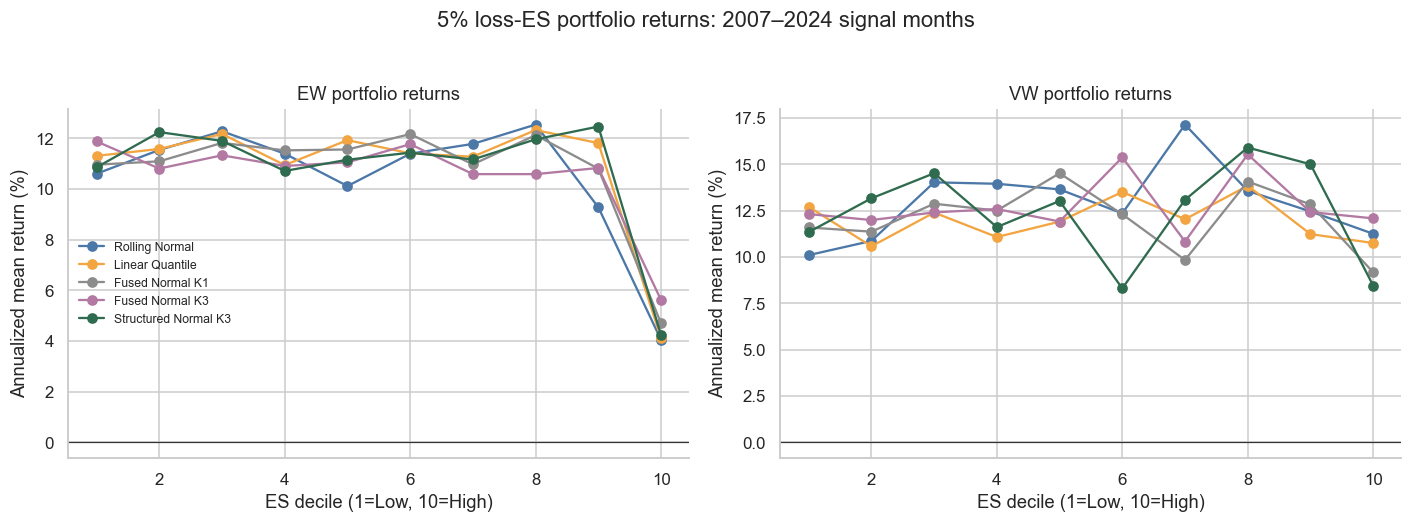

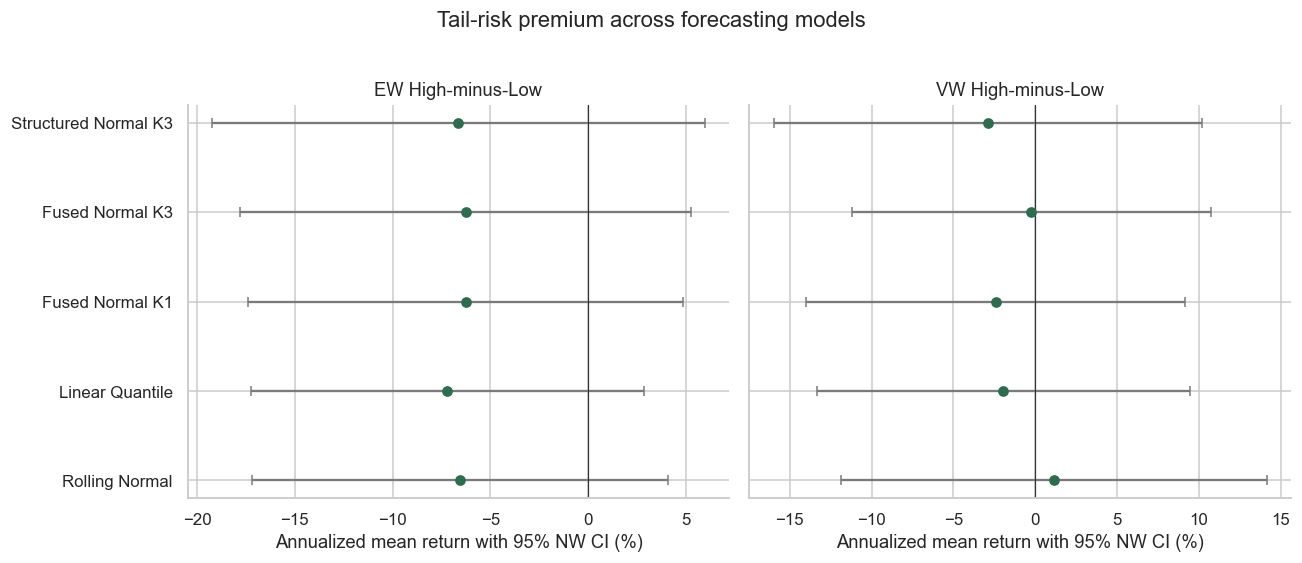

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig02_model_hml_intervals_20260831_1753.pdf')

In [11]:
# ==========================================
# 4.2 图：组合单调性与 H-L 置信区间
# ==========================================
portfolio_means = primary_portfolios.groupby(
    ["model_id", "model_label", "portfolio"], as_index=False
)[["ew_return", "vw_return"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for ax, weighting in zip(axes, ["ew", "vw"]):
    for model_id in model_order:
        data = portfolio_means[portfolio_means["model_id"] == model_id]
        ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                color=model_colors[model_id], label=model_labels[model_id])
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting.upper()} portfolio returns", xlabel="ES decile (1=Low, 10=High)", ylabel="Annualized mean return (%)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"{int(PRIMARY_ALPHA * 100)}% loss-ES portfolio returns: 2007–2024 signal months", y=1.03)
fig.tight_layout()
save_figure(fig, "fig01_model_portfolio_curves")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, weighting in zip(axes, ["EW", "VW"]):
    data = primary_hml_summary[primary_hml_summary["weighting"] == weighting].set_index("model_id").loc[model_order].reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["annualized_mean_pct"], y,
        xerr=[data["annualized_mean_pct"] - data["annualized_ci_low_pct"], data["annualized_ci_high_pct"] - data["annualized_mean_pct"]],
        fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} High-minus-Low", xlabel="Annualized mean return with 95% NW CI (%)", yticks=y, yticklabels=data["model_label"])
fig.suptitle("Tail-risk premium across forecasting models", y=1.02)
fig.tight_layout()
save_figure(fig, "fig02_model_hml_intervals")

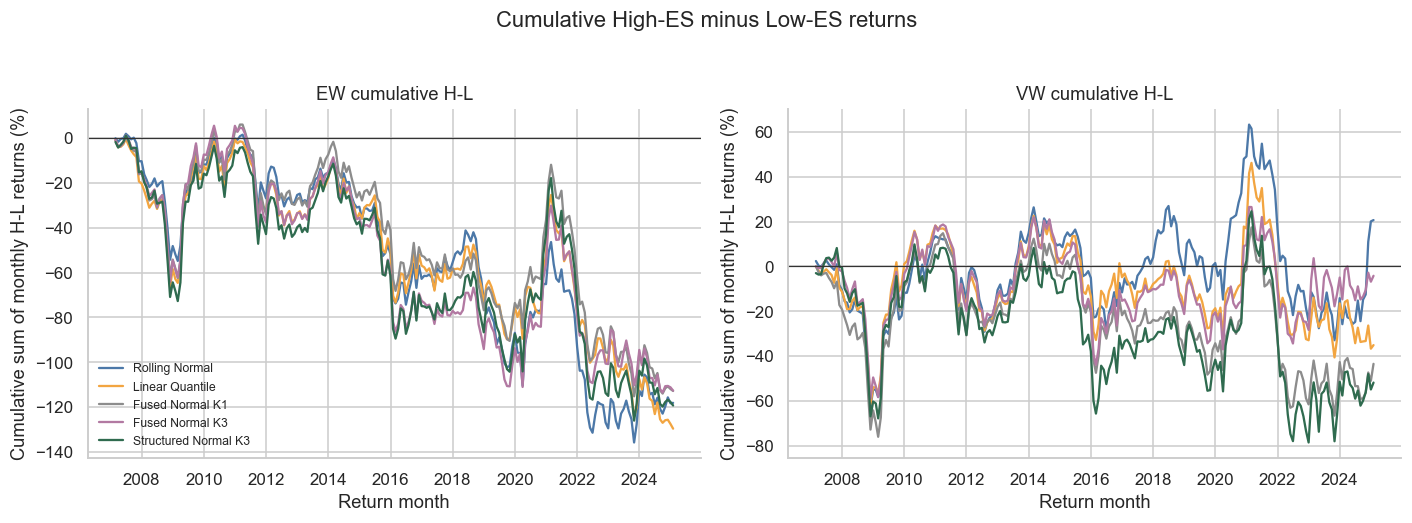

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig03_model_hml_cumulative_20260831_1753.pdf')

In [12]:
# ==========================================
# 4.3 图：H-L 累计收益和模型比较
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for ax, weighting in zip(axes, ["EW", "VW"]):
    for model_id in model_order:
        data = primary_hml[(primary_hml["model_id"] == model_id) & (primary_hml["weighting"] == weighting)].sort_values("return_date")
        ax.plot(data["return_date"], 100 * data["hml_return"].cumsum(), color=model_colors[model_id], label=model_labels[model_id])
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} cumulative H-L", xlabel="Return month", ylabel="Cumulative sum of monthly H-L returns (%)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Cumulative High-ES minus Low-ES returns", y=1.03)
fig.tight_layout()
save_figure(fig, "fig03_model_hml_cumulative")

## 5. Structured ES 的经济分解

以下比较总 ES、adverse component 对总 ES 的精确贡献，以及 adverse component 条件损失程度。`pi_adverse` 是同月共同变量，不能用于月内股票排序。

In [13]:
# ==========================================
# 5.1 Adverse contribution 与 severity 组合
# ==========================================
mechanism_specs = {
    "structured_adverse_contribution": ("Adverse contribution", "es_contribution_adverse_5"),
    "structured_adverse_severity": ("Adverse severity", "severity_adverse_5"),
}
mechanism_portfolio_parts, mechanism_hml_parts = [], []

for model_id, (signal_name, signal_col) in mechanism_specs.items():
    portfolios = sort_portfolios(pricing_base, signal_col, PRIMARY_GROUPS, me_breakpoints, False, breakpoint_universe="NYSE",)
    metadata = {
        "model_id": model_id, "model_label": signal_name, "signal_name": signal_name,
        "n_groups": PRIMARY_GROUPS, "exclude_microcaps": False, "breakpoint_universe": "NYSE",
    }
    for key, value in metadata.items():
        portfolios[key] = value
    mechanism_portfolio_parts.append(portfolios)
    mechanism_hml_parts.append(build_hml(portfolios, metadata))

mechanism_portfolios = pd.concat(mechanism_portfolio_parts, ignore_index=True)
mechanism_hml = pd.concat(mechanism_hml_parts, ignore_index=True)
mechanism_hml_summary = summarize_hml(mechanism_hml)

structured_total_portfolios = primary_portfolios[primary_portfolios["model_id"] == "structured_normal_k3"].copy()
structured_total_hml = primary_hml[primary_hml["model_id"] == "structured_normal_k3"].copy()
structured_portfolios = pd.concat([structured_total_portfolios, mechanism_portfolios], ignore_index=True)
structured_hml = pd.concat([structured_total_hml, mechanism_hml], ignore_index=True)

display(pd.concat([structured_portfolios.head(),structured_portfolios.tail()]))
display(pd.concat([structured_hml.head(),structured_hml.tail()]))

display(pd.concat([
    primary_hml_summary[primary_hml_summary["model_id"] == "structured_normal_k3"],
    mechanism_hml_summary,
], ignore_index=True)[["signal_name", "weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))

,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,134,0.125709,0.014418,1.223366e+09,0.011955,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
1,2007-01-31,2007-02-28,2,156,0.154435,0.005105,3.417408e+09,-0.015512,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
2,2007-01-31,2007-02-28,3,156,0.174121,0.005295,2.009714e+09,-0.028358,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
3,2007-01-31,2007-02-28,4,184,0.195673,0.001787,9.571114e+08,-0.007592,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
4,2007-01-31,2007-02-28,5,198,0.217219,0.006738,9.346608e+08,-0.027652,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
6475,2024-12-31,2025-01-31,6,170,0.168415,0.030575,4.487404e+09,-0.067209,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
6476,2024-12-31,2025-01-31,7,188,0.181047,0.030812,7.505598e+08,0.062014,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
6477,2024-12-31,2025-01-31,8,206,0.198575,0.028869,6.062601e+08,0.045603,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
6478,2024-12-31,2025-01-31,9,231,0.227290,0.034421,5.459739e+08,0.113220,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
6479,2024-12-31,2025-01-31,10,549,0.343679,0.013963,1.191366e+09,0.064080,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.017672,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
1,2007-02-28,2007-03-31,-0.024310,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
2,2007-03-31,2007-04-30,0.011649,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
3,2007-04-30,2007-05-31,0.013486,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
4,2007-05-31,2007-06-30,0.027613,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,NYSE
1291,2024-08-31,2024-09-30,0.006076,VW,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
1292,2024-09-30,2024-10-31,0.037783,VW,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
1293,2024-10-31,2024-11-30,0.076397,VW,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
1294,2024-11-30,2024-12-31,-0.072577,VW,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE
1295,2024-12-31,2025-01-31,0.057191,VW,structured_adverse_severity,Adverse severity,Adverse severity,10,False,NYSE


,signal_name,weighting,annualized_mean_pct,nw_t,p_value
0,Total ES (5%),EW,-6.6274,-1.0315,0.3023
1,Total ES (5%),VW,-2.8807,-0.4312,0.6663
2,Adverse contribution,EW,0.0974,0.0133,0.9894
3,Adverse contribution,VW,0.0672,0.0090,0.9929
4,Adverse severity,EW,-6.5464,-1.0081,0.3134
5,Adverse severity,VW,-2.3877,-0.3518,0.7250


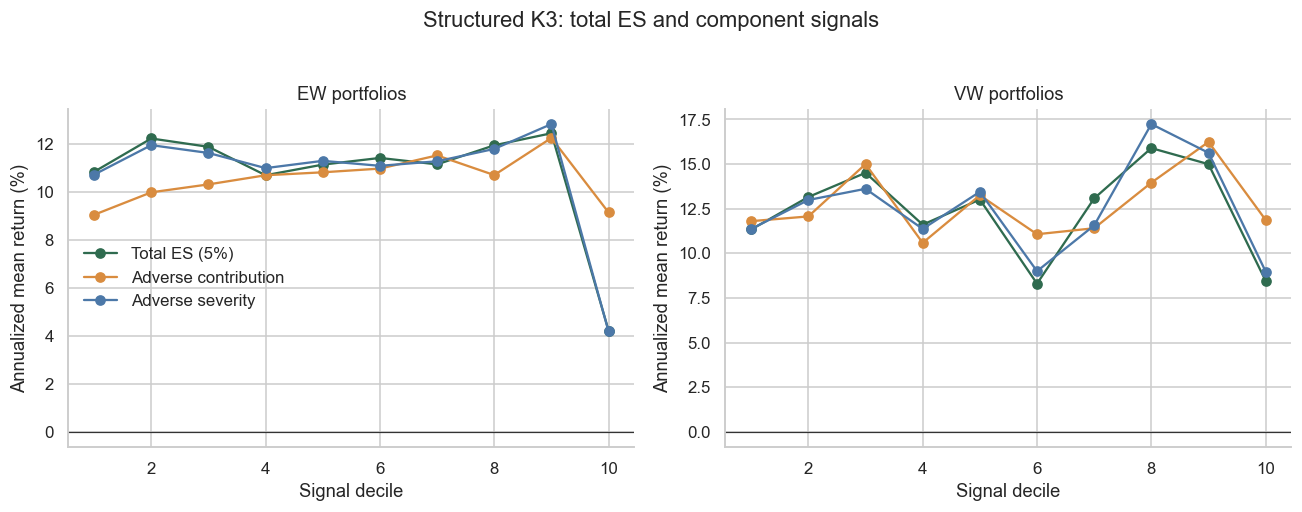

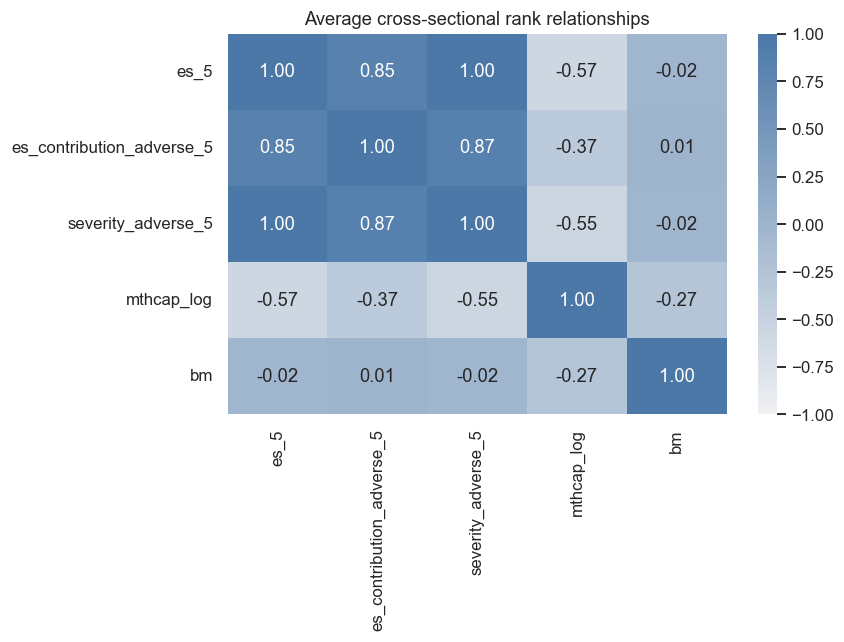

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig05_signal_correlation_20260831_1753.pdf')

In [14]:
# ==========================================
# 5.2 图：Structured signals 的组合收益与相关性
# ==========================================
structured_means = structured_portfolios.groupby(["signal_name", "portfolio"], as_index=False)[["ew_return", "vw_return"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, weighting in zip(axes, ["ew", "vw"]):
    for signal_name in signal_colors:
        data = structured_means[structured_means["signal_name"] == signal_name]
        ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                color=signal_colors[signal_name], label=signal_name)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting.upper()} portfolios", xlabel="Signal decile", ylabel="Annualized mean return (%)")
axes[0].legend(frameon=False)
fig.suptitle("Structured K3: total ES and component signals", y=1.03)
fig.tight_layout()
save_figure(fig, "fig04_structured_signal_portfolios")

corr_cols = ["es_5", "es_contribution_adverse_5", "severity_adverse_5", *control_cols]
ranked = pricing_base.groupby("mthcaldt")[corr_cols].rank(pct=True)
signal_correlation = ranked.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(signal_correlation, annot=True, fmt=".2f", cmap=sns.light_palette("#4C78A8", as_cmap=True), vmin=-1, vmax=1, ax=ax)
ax.set_title("Average cross-sectional rank relationships")
fig.tight_layout()
save_figure(fig, "fig05_signal_correlation")

## 6. 因子调整 alpha

H–L 是零成本组合，因此不减 risk-free rate。组合收益使用下一月日期与 CAPM、FF3、Carhart4、FF5 和 FF5+Momentum 因子对齐。

In [15]:
# ==========================================
# 6.1 H-L factor regressions
# ==========================================
factor_models = {
    "CAPM": ["mktrf_ff3"],
    "FF3": ["mktrf_ff3", "smb_ff3", "hml_ff3"],
    "Carhart4": ["mktrf_ff3", "smb_ff3", "hml_ff3", "umd_ff3"],
    "FF5": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5"],
    "FF5+MOM": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5", "umd_ff5"],
}


def run_factor_regressions(hml):
    alpha_rows, coefficient_rows = [], []
    group_cols = ["model_id", "model_label", "signal_name", "weighting"]
    for keys, group in hml.groupby(group_cols):
        data = group.merge(factor_data, on="return_date", how="inner")
        for specification, factors in factor_models.items():
            regression = data[["hml_return"] + factors].dropna()
            fit = sm.OLS(regression["hml_return"], sm.add_constant(regression[factors])).fit(
                cov_type="HAC", cov_kwds={"maxlags": min(NW_LAGS, len(regression) - 1)}
            )
            ci = fit.conf_int().loc["const"]
            row = dict(zip(group_cols, keys))
            row.update({
                "specification": specification, "alpha_monthly": fit.params["const"],
                "alpha_annualized_pct": 1200 * fit.params["const"], "nw_t": fit.tvalues["const"],
                "p_value": fit.pvalues["const"], "ci_95_low_pct": 1200 * ci.iloc[0],
                "ci_95_high_pct": 1200 * ci.iloc[1], "r_squared": fit.rsquared, "months": int(fit.nobs),
            })
            alpha_rows.append(row)
            for parameter in fit.params.index:
                coefficient_rows.append({**row, "parameter": parameter, "coefficient": fit.params[parameter], "parameter_t": fit.tvalues[parameter]})
    return pd.DataFrame(alpha_rows), pd.DataFrame(coefficient_rows)


hml_for_factors = pd.concat([primary_hml, mechanism_hml], ignore_index=True)
factor_alphas, factor_coefficients = run_factor_regressions(hml_for_factors)
# display(factor_alphas[factor_alphas["specification"] == "FF5+MOM"][[
#     "model_label", "signal_name", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
# ]].round(4))

# display(factor_alphas[[
#     "model_label", "signal_name", "specification", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
# ]].round(4))

display(factor_alphas)
display(factor_coefficients)

,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,-0.011962,-14.354570,-3.435352,0.000592,-22.544251,-6.164889,0.324173,216
1,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,-0.009321,-11.185525,-4.020342,0.000058,-16.638601,-5.732450,0.669243,216
2,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,Carhart4,-0.008553,-10.263865,-4.006506,0.000062,-15.284900,-5.242830,0.698800,216
3,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF5,-0.005123,-6.147326,-2.591006,0.009570,-10.797465,-1.497187,0.754713,216
4,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF5+MOM,-0.004447,-5.336102,-2.668854,0.007611,-9.254850,-1.417353,0.782102,216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,CAPM,-0.010771,-12.925260,-2.750951,0.005942,-22.134090,-3.716430,0.350310,216
66,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF3,-0.008158,-9.789811,-2.701059,0.006912,-16.893572,-2.686051,0.674187,216
67,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,Carhart4,-0.007189,-8.627036,-2.500079,0.012417,-15.390294,-1.863779,0.707141,216
68,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5,-0.002423,-2.907433,-1.034307,0.300992,-8.416883,2.602016,0.778653,216


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months,parameter,coefficient,parameter_t
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,-0.011962,-14.354570,-3.435352,0.000592,-22.544251,-6.164889,0.324173,216,const,-0.011962,-3.435352
1,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,-0.011962,-14.354570,-3.435352,0.000592,-22.544251,-6.164889,0.324173,216,mktrf_ff3,0.800666,8.230754
2,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,-0.009321,-11.185525,-4.020342,0.000058,-16.638601,-5.732450,0.669243,216,const,-0.009321,-4.020342
3,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,-0.009321,-11.185525,-4.020342,0.000058,-16.638601,-5.732450,0.669243,216,mktrf_ff3,0.525095,5.835705
4,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,-0.009321,-11.185525,-4.020342,0.000058,-16.638601,-5.732450,0.669243,216,smb_ff3,1.608442,9.731065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,-0.001602,-1.921996,-0.759433,0.447594,-6.882333,3.038340,0.806964,216,smb_ff5,1.317927,10.323613
332,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,-0.001602,-1.921996,-0.759433,0.447594,-6.882333,3.038340,0.806964,216,hml_ff5,-0.382664,-3.848758
333,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,-0.001602,-1.921996,-0.759433,0.447594,-6.882333,3.038340,0.806964,216,rmw_ff5,-1.401282,-9.020407
334,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,-0.001602,-1.921996,-0.759433,0.447594,-6.882333,3.038340,0.806964,216,cma_ff5,-0.424216,-1.980071


In [16]:
plot_alpha = factor_alphas[factor_alphas["specification"] == "FF3"].copy()
plot_alpha

,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months
1,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,-0.009321,-11.185525,-4.020342,0.000058,-16.638601,-5.732450,0.669243,216
6,fused_normal_k1,Fused Normal K1,Total ES (5%),VW,FF3,-0.006389,-7.666878,-2.243072,0.024892,-14.366085,-0.967672,0.638868,216
11,fused_normal_k3,Fused Normal K3,Total ES (5%),EW,FF3,-0.009539,-11.446222,-3.611920,0.000304,-17.657374,-5.235070,0.685263,216
16,fused_normal_k3,Fused Normal K3,Total ES (5%),VW,FF3,-0.005021,-6.025657,-1.749162,0.080263,-12.777502,0.726187,0.636833,216
21,linear_quantile,Linear Quantile,Total ES (5%),EW,FF3,-0.009168,-11.001945,-4.349424,0.000014,-15.959708,-6.044181,0.669806,216
26,linear_quantile,Linear Quantile,Total ES (5%),VW,FF3,-0.005045,-6.053417,-1.849661,0.064362,-12.467824,0.360990,0.645196,216
31,rolling_normal,Rolling Normal,Total ES (5%),EW,FF3,-0.010124,-12.149068,-4.199527,0.000027,-17.819168,-6.478969,0.661141,216
36,rolling_normal,Rolling Normal,Total ES (5%),VW,FF3,-0.004332,-5.198157,-1.390596,0.164348,-12.524656,2.128343,0.647382,216
41,structured_adverse_contribution,Adverse contribution,Adverse contribution,EW,FF3,-0.006051,-7.260657,-1.629627,0.103180,-15.993104,1.471789,0.645463,216
46,structured_adverse_contribution,Adverse contribution,Adverse contribution,VW,FF3,-0.005983,-7.180086,-1.695233,0.090031,-15.481430,1.121258,0.601213,216


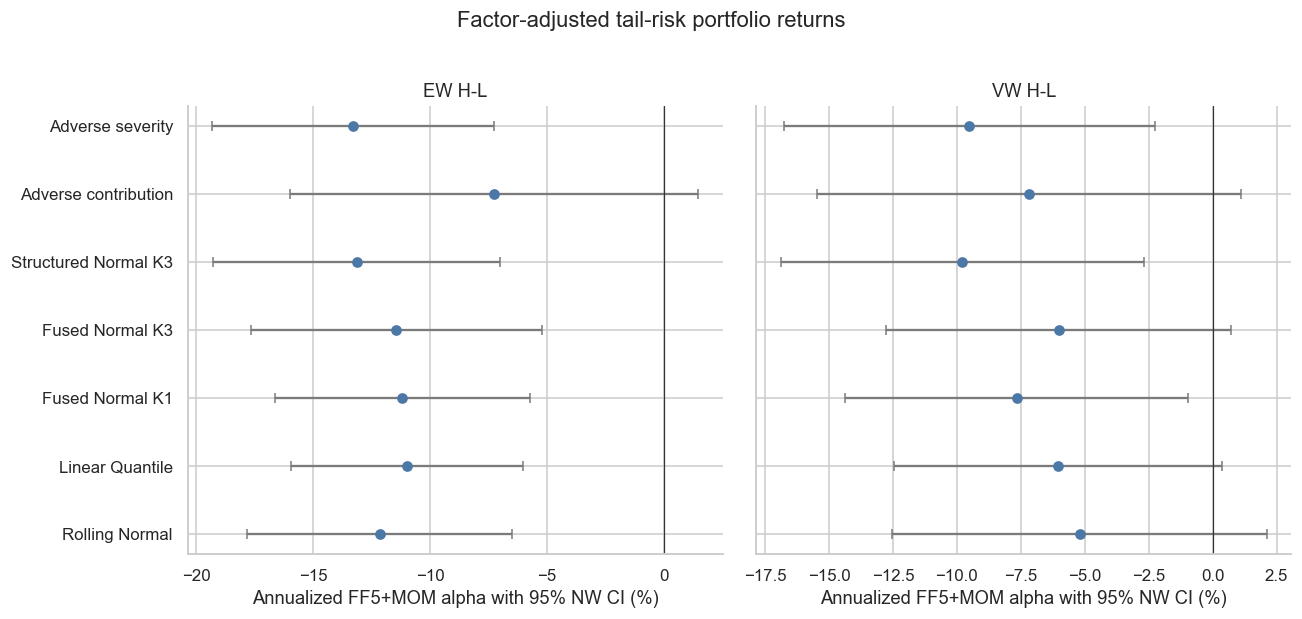

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig06_factor_alpha_20260831_1753.pdf')

In [17]:
# ==========================================
# 6.2 图：FF5+Momentum alpha
# ==========================================
plot_alpha = factor_alphas[factor_alphas["specification"] == "FF3"].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
for ax, weighting in zip(axes, ["EW", "VW"]):
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} H-L", xlabel="Annualized FF5+MOM alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
fig.suptitle("Factor-adjusted tail-risk portfolio returns", y=1.02)
fig.tight_layout()
save_figure(fig, "fig06_factor_alpha")

## 7. Fama–MacBeth 横截面回归

连续变量每月先在 1%/99% winsorize，再标准化。所有规格使用相同的 non-missing control sample：

1. Univariate；
2. Controls：size、book-to-market、momentum、历史波动率；
3. Controls + FF49 industry fixed effects。

In [18]:
# ==========================================
# 7.1 月度横截面回归函数
# ==========================================
def standardize_monthly(panel, columns):
    result = panel.copy()
    for column in columns:
        grouped = result.groupby("mthcaldt")[column]
        lower = grouped.transform(lambda x: x.quantile(0.01))
        upper = grouped.transform(lambda x: x.quantile(0.99))
        clipped = result[column].clip(lower=lower, upper=upper)
        mean = clipped.groupby(result["mthcaldt"]).transform("mean")
        std = clipped.groupby(result["mthcaldt"]).transform("std")
        result[f"z_{column}"] = (clipped - mean) / std
    return result


def run_fama_macbeth(panel, signal_col, model_id, model_label, signal_name):
    required = ["mthcaldt", "target_ret_final", industry_type, signal_col, *control_cols]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work = standardize_monthly(work, [signal_col, *control_cols])
    z_signal = f"z_{signal_col}"
    z_controls = [f"z_{column}" for column in control_cols]
    specifications = {
        "Univariate": ([], False), "Controls": (z_controls, False),
        "Controls+IndustryFE": (z_controls, True),
    }

    rows = []
    for month, group in work.groupby("mthcaldt", sort=True):
        y = group["target_ret_final"].to_numpy(dtype=float)
        for specification, (controls, industry_fe) in specifications.items():
            X = group[[z_signal] + controls].to_numpy(dtype=float)
            if industry_fe:
                industry = pd.get_dummies(group[industry_type].astype(int), drop_first=True, dtype=float).to_numpy()
                X = np.column_stack([X, industry])
            X = np.column_stack([np.ones(len(group)), X])
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            residual = y - X @ beta
            total_ss = np.sum((y - y.mean()) ** 2)
            rows.append({
                "mthcaldt": month, "model_id": model_id, "model_label": model_label,
                "signal_name": signal_name, "specification": specification,
                "signal_slope": beta[1], "r_squared": 1 - np.sum(residual ** 2) / total_ss,
                "n_firms": len(group),
            })
    return pd.DataFrame(rows)


def summarize_fama_macbeth(slopes):
    rows = []
    group_cols = ["model_id", "model_label", "signal_name", "specification"]
    for keys, group in slopes.groupby(group_cols):
        row = dict(zip(group_cols, keys))
        row.update(nw_mean(group["signal_slope"]))
        row["annualized_slope_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

In [19]:
# ==========================================
# 7.2 所有模型 ES、adverse contribution 和 severity
# ==========================================
fmb_parts = []
for model_id in model_order:
    print("Fama-MacBeth:", model_labels[model_id])
    panel = load_model_panel(model_id, PRIMARY_ALPHA)
    fmb_parts.append(run_fama_macbeth(panel, "signal", model_id, model_labels[model_id], "Total ES (5%)"))

for model_id, (signal_name, signal_col) in mechanism_specs.items():
    fmb_parts.append(run_fama_macbeth(pricing_base, signal_col, model_id, signal_name, signal_name))

fmb_monthly_slopes = pd.concat(fmb_parts, ignore_index=True)
fmb_summary = summarize_fama_macbeth(fmb_monthly_slopes)
display(fmb_summary[fmb_summary["specification"] == "Controls"][[
    "model_label", "signal_name", "annualized_slope_pct", "nw_t", "p_value", "months"
]].round(4))

display(fmb_monthly_slopes)
display(fmb_summary)


Fama-MacBeth: Rolling Normal
Fama-MacBeth: Linear Quantile
Fama-MacBeth: Fused Normal K1
Fama-MacBeth: Fused Normal K3
Fama-MacBeth: Structured Normal K3


,model_label,signal_name,annualized_slope_pct,nw_t,p_value,months
0,Fused Normal K1,Total ES (5%),-3.1526,-1.8255,0.0679,216
3,Fused Normal K3,Total ES (5%),-2.8040,-1.6178,0.1057,216
6,Linear Quantile,Total ES (5%),-3.7083,-2.0715,0.0383,216
9,Rolling Normal,Total ES (5%),-3.2900,-2.3138,0.0207,216
12,Adverse contribution,Adverse contribution,-0.5286,-0.2841,0.7763,216
15,Adverse severity,Adverse severity,-3.1244,-1.6393,0.1012,216
18,Structured Normal K3,Total ES (5%),-3.5689,-1.9069,0.0565,216


,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms
0,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Univariate,0.000997,0.000105,2753
1,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls,0.000243,0.004862,2753
2,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls+IndustryFE,0.000926,0.016448,2753
3,2007-02-28,rolling_normal,Rolling Normal,Total ES (5%),Univariate,-0.002684,0.000762,2769
4,2007-02-28,rolling_normal,Rolling Normal,Total ES (5%),Controls,-0.001989,0.001727,2769
...,...,...,...,...,...,...,...,...
4531,2024-11-30,structured_adverse_severity,Adverse severity,Adverse severity,Controls,-0.016627,0.012093,1969
4532,2024-11-30,structured_adverse_severity,Adverse severity,Adverse severity,Controls+IndustryFE,-0.013799,0.047574,1969
4533,2024-12-31,structured_adverse_severity,Adverse severity,Adverse severity,Univariate,-0.010441,0.005741,1932
4534,2024-12-31,structured_adverse_severity,Adverse severity,Adverse severity,Controls,-0.006495,0.010333,1932


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls,-0.002627,0.001439,-1.825543,0.067919,-0.005448,0.000194,216,-3.152640,-6.537481,0.232201
1,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls+IndustryFE,-0.002654,0.001541,-1.722916,0.084904,-0.005674,0.000365,216,-3.184983,-6.808241,0.438274
2,fused_normal_k1,Fused Normal K1,Total ES (5%),Univariate,-0.002468,0.001405,-1.757024,0.078914,-0.005221,0.000285,216,-2.961477,-6.265071,0.342117
3,fused_normal_k3,Fused Normal K3,Total ES (5%),Controls,-0.002337,0.001444,-1.617818,0.105702,-0.005167,0.000494,216,-2.803950,-6.200960,0.593059
4,fused_normal_k3,Fused Normal K3,Total ES (5%),Controls+IndustryFE,-0.002327,0.001498,-1.553410,0.120325,-0.005264,0.000609,216,-2.792970,-6.316972,0.731033
5,fused_normal_k3,Fused Normal K3,Total ES (5%),Univariate,-0.002411,0.001391,-1.733379,0.083028,-0.005138,0.000315,216,-2.893738,-6.165802,0.378325
6,linear_quantile,Linear Quantile,Total ES (5%),Controls,-0.003090,0.001492,-2.071516,0.038311,-0.006014,-0.000166,216,-3.708317,-7.217003,-0.199631
7,linear_quantile,Linear Quantile,Total ES (5%),Controls+IndustryFE,-0.003117,0.001506,-2.070269,0.038427,-0.006068,-0.000166,216,-3.740714,-7.282186,-0.199242
8,linear_quantile,Linear Quantile,Total ES (5%),Univariate,-0.002749,0.001385,-1.984570,0.047192,-0.005464,-0.000034,216,-3.298958,-6.557073,-0.040842
9,rolling_normal,Rolling Normal,Total ES (5%),Controls,-0.002742,0.001185,-2.313766,0.020681,-0.005064,-0.000419,216,-3.289983,-6.076940,-0.503026


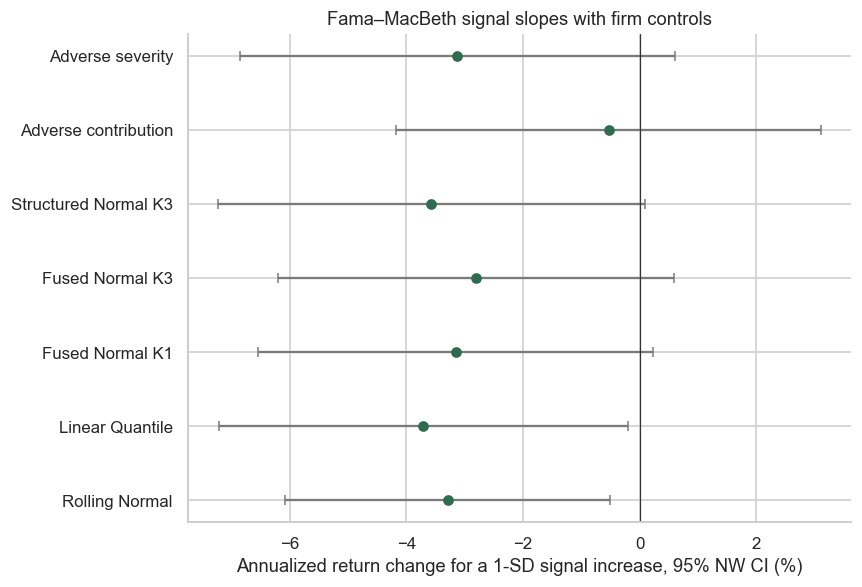

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig07_fama_macbeth_20260831_1753.pdf')

In [20]:
# ==========================================
# 7.3 图：控制变量后的 Fama-MacBeth slopes
# ==========================================
plot_fmb = fmb_summary[fmb_summary["specification"] == "Controls"].copy()
plot_fmb["series_label"] = np.where(
    plot_fmb["signal_name"] == "Total ES (5%)", plot_fmb["model_label"], plot_fmb["signal_name"]
)
series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
plot_fmb = plot_fmb.set_index("series_label").reindex(series_order).dropna().reset_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(plot_fmb))
ax.errorbar(
    plot_fmb["annualized_slope_pct"], y,
    xerr=[plot_fmb["annualized_slope_pct"] - plot_fmb["annualized_ci_low_pct"], plot_fmb["annualized_ci_high_pct"] - plot_fmb["annualized_slope_pct"]],
    fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(
    title="Fama–MacBeth signal slopes with firm controls",
    xlabel="Annualized return change for a 1-SD signal increase, 95% NW CI (%)",
    yticks=y, yticklabels=plot_fmb["series_label"],
)
fig.tight_layout()
save_figure(fig, "fig07_fama_macbeth")

## 8. Adverse weight 与 severity premium

`pi_adverse` 是每个月共同的 adverse-component probability，
不参与股票的月内横截面排序。

本节的主检验使用全样本标准化的连续 `pi_adverse`，检验：

1. H–L portfolio return 是否随 global adverse weight 变化；
2. 月度 Fama–MacBeth severity slope 是否随 global adverse weight 变化；
3. 个股层 severity × adverse-weight interaction 是否显著。

为展示经济量级，另外比较全样本 `pi_adverse` 最高三分之一和
最低三分之一的月份。加入 window fixed effects 或使用 within-window
standardization 的结果仅作为稳健性检验。

In [21]:
# ==========================================
# 8.1 构造 global adverse-weight state
# ==========================================

state_monthly = (pricing_base.groupby("mthcaldt",as_index=False,)
    .agg(pi_adverse=("pi_adverse", "first"), window=("window", "first"),)
    .sort_values("mthcaldt").reset_index(drop=True)
)

# 主状态变量：全样本标准化
pi_mean = state_monthly["pi_adverse"].mean()
pi_std = state_monthly["pi_adverse"].std(ddof=1)

state_monthly["pi_adverse_global_z"] = (state_monthly["pi_adverse"] - pi_mean) / pi_std

# 全样本 percentile rank，用于图和状态分组
state_monthly["pi_rank_global"] = state_monthly["pi_adverse"].rank(pct=True)

# Within-window z-score 只保留为稳健性检验
window_mean = state_monthly.groupby("window")["pi_adverse"].transform("mean")

window_std = state_monthly.groupby("window")["pi_adverse"].transform("std", ddof=1)

state_monthly["pi_adverse_within_z"] = (state_monthly["pi_adverse"] - window_mean) / window_std

# 全样本最高/最低三分之一
low_cutoff = state_monthly["pi_adverse"].quantile(1 / 3)
high_cutoff = state_monthly["pi_adverse"].quantile(2 / 3)

state_monthly["adverse_state_global"] = np.select(
    [
        state_monthly["pi_adverse"] <= low_cutoff,
        state_monthly["pi_adverse"] >= high_cutoff,
    ],
    [
        "Low global tercile",
        "High global tercile",
    ],
    default="Middle",
)

In [22]:
def continuous_hml_state_test(hml, state):
    # 回归模型: hml_return ~ pi_adverse_global_z + window FE (optional)
    rows = []

    group_cols = ["model_id", "model_label", "signal_name", "weighting",]

    state_specs = [
        (
            "Global",
            "pi_adverse_global_z",
            False,
        ),
        (
            "Global + window FE",
            "pi_adverse_global_z",
            True,
        ),
    ]

    for keys, group in hml.groupby(group_cols):
        merged = group.merge(state[["mthcaldt", "window", "pi_adverse_global_z",]],on="mthcaldt",validate="one_to_one",)

        for specification, state_col, add_window_fe in state_specs:
            data = merged[
                [
                    "hml_return",
                    state_col,
                    "window",
                ]
            ].dropna().reset_index(drop=True)

            X = pd.DataFrame(
                {
                    "const": 1.0,
                    state_col: data[state_col],
                }
            )

            if add_window_fe:
                window_dummies = pd.get_dummies(
                    data["window"],
                    prefix="window",
                    drop_first=True,
                    dtype=float,
                )

                X = pd.concat(
                    [X, window_dummies],
                    axis=1,
                )

            fit = sm.OLS(
                data["hml_return"],
                X,
            ).fit(
                cov_type="HAC",
                cov_kwds={
                    "maxlags": min(
                        NW_LAGS,
                        len(data) - 1,
                    )
                },
            )

            ci = fit.conf_int().loc[state_col]

            rows.append(
                {
                    **dict(zip(group_cols, keys)),
                    "state_specification": specification,
                    "state_variable": state_col,
                    "coefficient": fit.params[state_col],
                    "annualized_coefficient_pct":
                        1200 * fit.params[state_col],
                    "nw_t": fit.tvalues[state_col],
                    "p_value": fit.pvalues[state_col],
                    "ci_95_low_pct": 1200 * ci.iloc[0],
                    "ci_95_high_pct": 1200 * ci.iloc[1],
                    "months": int(fit.nobs),
                }
            )

    return pd.DataFrame(rows)


state_hml_continuous = continuous_hml_state_test(
    mechanism_hml,
    state_monthly,
)

display(
    state_hml_continuous[
        [
            "signal_name",
            "weighting",
            "state_specification",
            "annualized_coefficient_pct",
            "nw_t",
            "p_value",
            "months",
        ]
    ].round(4)
)

,signal_name,weighting,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Adverse contribution,EW,Global,-9.5432,-1.7503,0.0801,216
1,Adverse contribution,EW,Global + window FE,-20.1729,-2.7785,0.0055,216
2,Adverse contribution,VW,Global,-2.5791,-0.4656,0.6415,216
3,Adverse contribution,VW,Global + window FE,-15.2978,-1.9760,0.0482,216
4,Adverse severity,EW,Global,-2.4993,-0.4960,0.6199,216
5,Adverse severity,EW,Global + window FE,-16.1032,-2.3693,0.0178,216
6,Adverse severity,VW,Global,1.5398,0.2888,0.7728,216
7,Adverse severity,VW,Global + window FE,-12.4497,-1.5563,0.1196,216


In [23]:
data = state_hml_continuous[state_hml_continuous["weighting"] == weighting].copy()
data

,model_id,model_label,signal_name,weighting,state_specification,state_variable,coefficient,annualized_coefficient_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,months
2,structured_adverse_contribution,Adverse contribution,Adverse contribution,VW,Global,pi_adverse_global_z,-0.002149,-2.579108,-0.465588,0.641511,-13.436264,8.278047,216
3,structured_adverse_contribution,Adverse contribution,Adverse contribution,VW,Global + window FE,pi_adverse_global_z,-0.012748,-15.297757,-1.976017,0.048153,-30.471236,-0.124277,216
6,structured_adverse_severity,Adverse severity,Adverse severity,VW,Global,pi_adverse_global_z,0.001283,1.539777,0.288758,0.772766,-8.911552,11.991107,216
7,structured_adverse_severity,Adverse severity,Adverse severity,VW,Global + window FE,pi_adverse_global_z,-0.010375,-12.449656,-1.556269,0.119644,-28.128741,3.229428,216


In [24]:
state_monthly

,mthcaldt,pi_adverse,window,pi_adverse_global_z,pi_rank_global,pi_adverse_within_z,adverse_state_global
0,2007-01-31,0.596651,0,0.718123,0.685185,-1.257502,High global tercile
1,2007-02-28,0.764886,0,1.230799,0.824074,-0.145338,High global tercile
2,2007-03-31,0.805426,0,1.354340,0.865741,0.122664,High global tercile
3,2007-04-30,0.881491,0,1.586140,0.958333,0.625516,High global tercile
4,2007-05-31,0.905425,0,1.659074,0.972222,0.783734,High global tercile
...,...,...,...,...,...,...,...
211,2024-08-31,0.850594,17,1.491982,0.912037,0.446350,High global tercile
212,2024-09-30,0.796500,17,1.327139,0.861111,-0.549115,High global tercile
213,2024-10-31,0.686475,17,0.991850,0.736111,-2.573885,High global tercile
214,2024-11-30,0.849588,17,1.488917,0.907407,0.427837,High global tercile


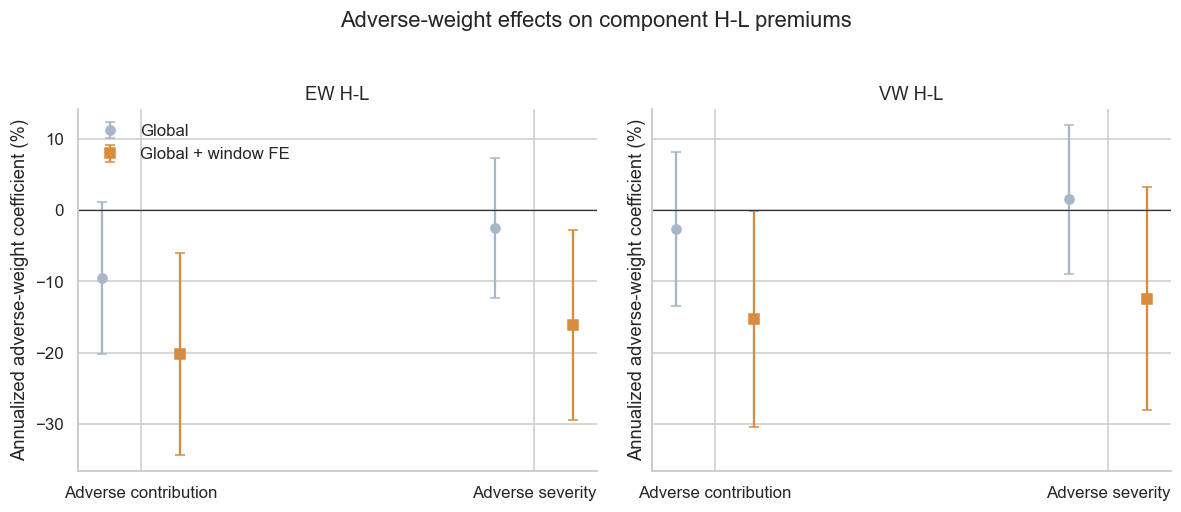

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig08_state_continuous_coefficients_20260831_1753.pdf')

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, weighting in zip(axes, ["EW", "VW"]):

    data = state_hml_continuous[
        state_hml_continuous["weighting"] == weighting
    ].copy()

    signals = ["Adverse contribution", "Adverse severity"]
    x = np.arange(len(signals))

    for offset, state_name, color, marker in [
        (-0.10, "Global", "#A7B7C7", "o"),
        (0.10, "Global + window FE", "#D98C3F", "s"),
    ]:

        state_data = (
            data[data["state_specification"] == state_name]
            .set_index("signal_name")
            .loc[signals]
        )

        ax.errorbar(
            x + offset,
            state_data["annualized_coefficient_pct"],
            yerr=[
                state_data["annualized_coefficient_pct"]
                - state_data["ci_95_low_pct"],
                state_data["ci_95_high_pct"]
                - state_data["annualized_coefficient_pct"],
            ],
            fmt=marker,
            color=color,
            capsize=3,
            label=state_name,
        )

    ax.axhline(0, color="#333333", linewidth=0.8)

    ax.set(
        title=f"{weighting} H-L",
        ylabel="Annualized adverse-weight coefficient (%)",
        xticks=x,
        xticklabels=signals,
        xlabel="",
    )

axes[0].legend(frameon=False)
fig.suptitle("Adverse-weight effects on component H-L premiums", y=1.03)
fig.tight_layout()

save_figure(fig, "fig08_state_continuous_coefficients")

,dependent_variable,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,monthly severity slope,Global,0.000228,0.197438,0.843485,216
1,monthly severity slope,Global + window FE,-0.002308,-1.511469,0.130669,216


[Text(0.5, 1.0, 'Severity price and global adverse weight'),
 Text(0.5, 0, 'Globally standardized pi_adverse'),
 Text(0, 0.5, 'Monthly severity slope (%)')]

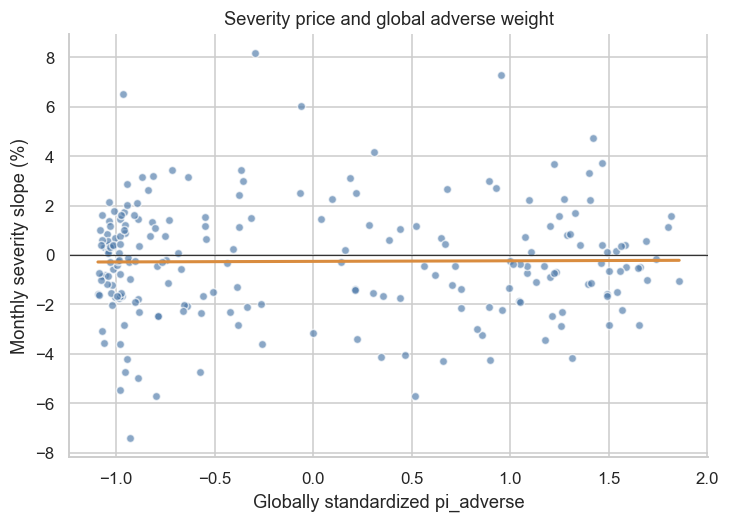

In [26]:
# ==========================================
# 8.3 月度 severity slope 对 adverse weight 的回归
# ==========================================
# 回归方程是: monthly_severity_slope = β0 + β1 * adverse_weight + ε
severity_slopes = fmb_monthly_slopes[
    (fmb_monthly_slopes["signal_name"] == "Adverse severity") &
    (fmb_monthly_slopes["specification"] == "Controls")
].merge(state_monthly, on="mthcaldt", validate="one_to_one")

rows = []

state_specs = [
    (
        "Global",
        "pi_adverse_global_z",
        False,
    ),
    (
        "Global + window FE",
        "pi_adverse_global_z",
        True,
    ),
]


for state_spec, x_col, add_window_fe in state_specs:
    X = pd.DataFrame({"const": 1.0, x_col: severity_slopes[x_col]})
    if add_window_fe:
        X = pd.concat([X, pd.get_dummies(severity_slopes["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
    fit_state = sm.OLS(severity_slopes["signal_slope"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
    rows.append({
        "dependent_variable": "monthly severity slope", "state_specification": state_spec,
        "coefficient_pi_adverse_z": fit_state.params[x_col], "nw_t": fit_state.tvalues[x_col],
        "p_value": fit_state.pvalues[x_col], "months": int(fit_state.nobs),
    })
state_slope_regression = pd.DataFrame(rows)
display(state_slope_regression.round(6))

visual_data = severity_slopes[
    [
        "signal_slope",
        "pi_adverse_global_z",
    ]
].dropna().copy()

fit_visual = sm.OLS(
    visual_data["signal_slope"],
    sm.add_constant(
        visual_data["pi_adverse_global_z"]
    ),
).fit()

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.scatter(
    visual_data["pi_adverse_global_z"],
    100 * visual_data["signal_slope"],
    s=28,
    alpha=0.65,
    color="#4C78A8",
    edgecolor="white",
)

x_line = np.linspace(
    visual_data["pi_adverse_global_z"].min(),
    visual_data["pi_adverse_global_z"].max(),
    100,
)

ax.plot(
    x_line,
    100 * (
        fit_visual.params["const"]
        + fit_visual.params["pi_adverse_global_z"]
        * x_line
    ),
    color="#D98C3F",
    linewidth=2,
)

ax.axhline(
    0,
    color="#333333",
    linewidth=0.8,
)

ax.set(
    title="Severity price and global adverse weight",
    xlabel="Globally standardized pi_adverse",
    ylabel="Monthly severity slope (%)",
)


# severity_slopes["slope_within"] = severity_slopes["signal_slope"] - severity_slopes.groupby("window")["signal_slope"].transform("mean")
# fit_visual = sm.OLS(severity_slopes["slope_within"], sm.add_constant(severity_slopes["pi_adverse_within_z"])).fit()
# fig, ax = plt.subplots(figsize=(7.5, 5))
# ax.scatter(severity_slopes["pi_adverse_within_z"], 100 * severity_slopes["slope_within"], s=28, alpha=0.65, color="#4C78A8", edgecolor="white")
# x_line = np.linspace(severity_slopes["pi_adverse_within_z"].min(), severity_slopes["pi_adverse_within_z"].max(), 100)
# ax.plot(x_line, 100 * (fit_visual.params["const"] + fit_visual.params["pi_adverse_within_z"] * x_line), color="#D98C3F", linewidth=2)
# ax.axhline(0, color="#333333", linewidth=0.8)
# ax.set(title="Within-window severity price and adverse component weight", xlabel="Within-window standardized pi_adverse", ylabel="Window-demeaned monthly severity slope (%)")
# fig.tight_layout()
# save_figure(fig, "fig09_state_slope_scatter")


In [27]:
def pooled_state_interaction(
    panel,
    signal_col,
    signal_name,
    state,
):
    required = [
        "mthcaldt",
        "target_ret_final",
        signal_col,
        *control_cols,
    ]

    work = (
        panel[required]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    work = standardize_monthly(
        work,
        [signal_col, *control_cols],
    )

    work = work.merge(
        state[
            [
                "mthcaldt",
                "pi_adverse_global_z",
                "pi_adverse_within_z",
            ]
        ],
        on="mthcaldt",
        validate="many_to_one",
    )

    state_specs = [
        (
            "Global",
            "pi_adverse_global_z",
        ),
        (
            "Within-window robustness",
            "pi_adverse_within_z",
        ),
    ]

    rows = []

    for specification, state_col in state_specs:
        data = work.dropna(
            subset=[state_col]
        ).copy()

        data["interaction"] = (
            data[f"z_{signal_col}"]
            * data[state_col]
        )

        # 月份固定效应等价处理
        data["return_demeaned"] = (
            data["target_ret_final"]
            - data.groupby("mthcaldt")[
                "target_ret_final"
            ].transform("mean")
        )

        regressors = [
            f"z_{signal_col}",
            "interaction",
            *[
                f"z_{column}"
                for column in control_cols
            ],
        ]

        fit = sm.OLS(
            data["return_demeaned"],
            data[regressors],
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": pd.factorize(
                    data["mthcaldt"]
                )[0]
            },
        )

        for parameter in regressors:
            rows.append(
                {
                    "signal_name": signal_name,
                    "state_specification": specification,
                    "state_variable": state_col,
                    "parameter": parameter,
                    "coefficient":
                        fit.params[parameter],
                    "cluster_t":
                        fit.tvalues[parameter],
                    "p_value":
                        fit.pvalues[parameter],
                    "observations":
                        int(fit.nobs),
                    "months":
                        data["mthcaldt"].nunique(),
                }
            )

    return pd.DataFrame(rows)

pooled_interactions = pd.concat(
    [
        pooled_state_interaction(
            pricing_base,
            "severity_adverse_5",
            "Adverse severity",
            state_monthly,
        ),
        pooled_state_interaction(
            pricing_base,
            "es_contribution_adverse_5",
            "Adverse contribution",
            state_monthly,
        ),
    ],
    ignore_index=True,
)

display(
    pooled_interactions[
        (
            pooled_interactions["parameter"]
            == "interaction"
        )
        & (
            pooled_interactions[
                "state_specification"
            ]
            == "Global"
        )
    ].round(6)
)

,signal_name,state_specification,state_variable,parameter,coefficient,cluster_t,p_value,observations,months
1,Adverse severity,Global,pi_adverse_global_z,interaction,-0.000280,-0.228071,0.819591,459489,216
9,Adverse contribution,Global,pi_adverse_global_z,interaction,-0.002235,-1.897488,0.057764,459489,216


## 9. Structured ES 稳健性

只对预先固定的 Structured K3 检查：1%/5%/10% ES、五组/十组、NYSE/全样本 breakpoints，以及是否排除 NYSE size 第20百分位以下的 microcaps。该部分不能用于重新选择主模型。

In [28]:
# ==========================================
# 9.1 组合设计稳健性
# ==========================================
robustness_hml_parts = []
# for alpha in [0.01, 0.05, 0.10]:
#     panel = load_model_panel("structured_normal_k3", alpha)
#     for n_groups in [5, 10]:
#         for exclude_microcaps in [False, True]:
#             portfolios = sort_portfolios(panel, "signal", n_groups, me_breakpoints, exclude_microcaps, breakpoint_universe="NYSE",)
#             metadata = {
#                 "model_id": "structured_normal_k3", "model_label": "Structured Normal K3",
#                 "signal_name": f"Total ES ({alpha:.0%})", "n_groups": n_groups,
#                 "exclude_microcaps": exclude_microcaps, "breakpoint_universe": "NYSE",
#             }
#             hml = build_hml(portfolios, metadata)
#             hml["alpha"] = alpha
#             robustness_hml_parts.append(hml)

for alpha in [0.01, 0.05, 0.10]:
    panel = load_model_panel(
        "structured_normal_k3",
        alpha,
    )

    for n_groups in [5, 10]:
        for breakpoint_universe in ["NYSE", "All"]:
            for exclude_microcaps in [False, True]:

                portfolios = sort_portfolios(
                    panel=panel,
                    signal_col="signal",
                    n_groups=n_groups,
                    me_breakpoints_df=me_breakpoints,
                    exclude_microcaps=exclude_microcaps,
                    breakpoint_universe=breakpoint_universe,
                )

                metadata = {
                    "model_id": "structured_normal_k3",
                    "model_label": "Structured Normal K3",
                    "signal_name": f"Total ES ({alpha:.0%})",
                    "n_groups": n_groups,
                    "exclude_microcaps": exclude_microcaps,
                    "breakpoint_universe": breakpoint_universe,
                }

                for key, value in metadata.items():
                    portfolios[key] = value

                hml = build_hml(portfolios, metadata)
                hml["alpha"] = alpha
                robustness_hml_parts.append(hml)

robustness_hml = pd.concat(robustness_hml_parts, ignore_index=True)
robustness_summary = summarize_hml(robustness_hml)
robustness_summary["alpha"] = robustness_summary["signal_name"].str.extract(r"\((\d+)%\)")[0].astype(float) / 100
robustness_summary["design"] = (
    robustness_summary["n_groups"].astype(str)
    + " groups | "
    + robustness_summary["breakpoint_universe"]
    + " | "
    + np.where(
        robustness_summary["exclude_microcaps"],
        "no microcaps",
        "all caps",
    )
)
display_cols = [
    "alpha",
    "n_groups",
    "breakpoint_universe",
    "exclude_microcaps",
    "weighting",
    "annualized_mean_pct",
    "nw_t",
    "p_value",
]
display(robustness_summary[display_cols].round(4))

,alpha,n_groups,breakpoint_universe,exclude_microcaps,weighting,annualized_mean_pct,nw_t,p_value
0,0.01,5,All,False,EW,-8.5141,-1.5340,0.1250
1,0.01,5,NYSE,False,EW,-4.5355,-0.8731,0.3826
2,0.01,5,All,True,EW,-1.7516,-0.3381,0.7353
3,0.01,5,NYSE,True,EW,-0.6028,-0.1202,0.9043
4,0.01,10,All,False,EW,-12.8892,-1.9599,0.0500
5,0.01,10,NYSE,False,EW,-6.7398,-1.0487,0.2943
6,0.01,10,All,True,EW,-3.6064,-0.5832,0.5598
7,0.01,10,NYSE,True,EW,-1.4190,-0.2270,0.8205
8,0.01,5,All,False,VW,-5.0557,-0.8450,0.3981
9,0.01,5,NYSE,False,VW,-0.6333,-0.1202,0.9044


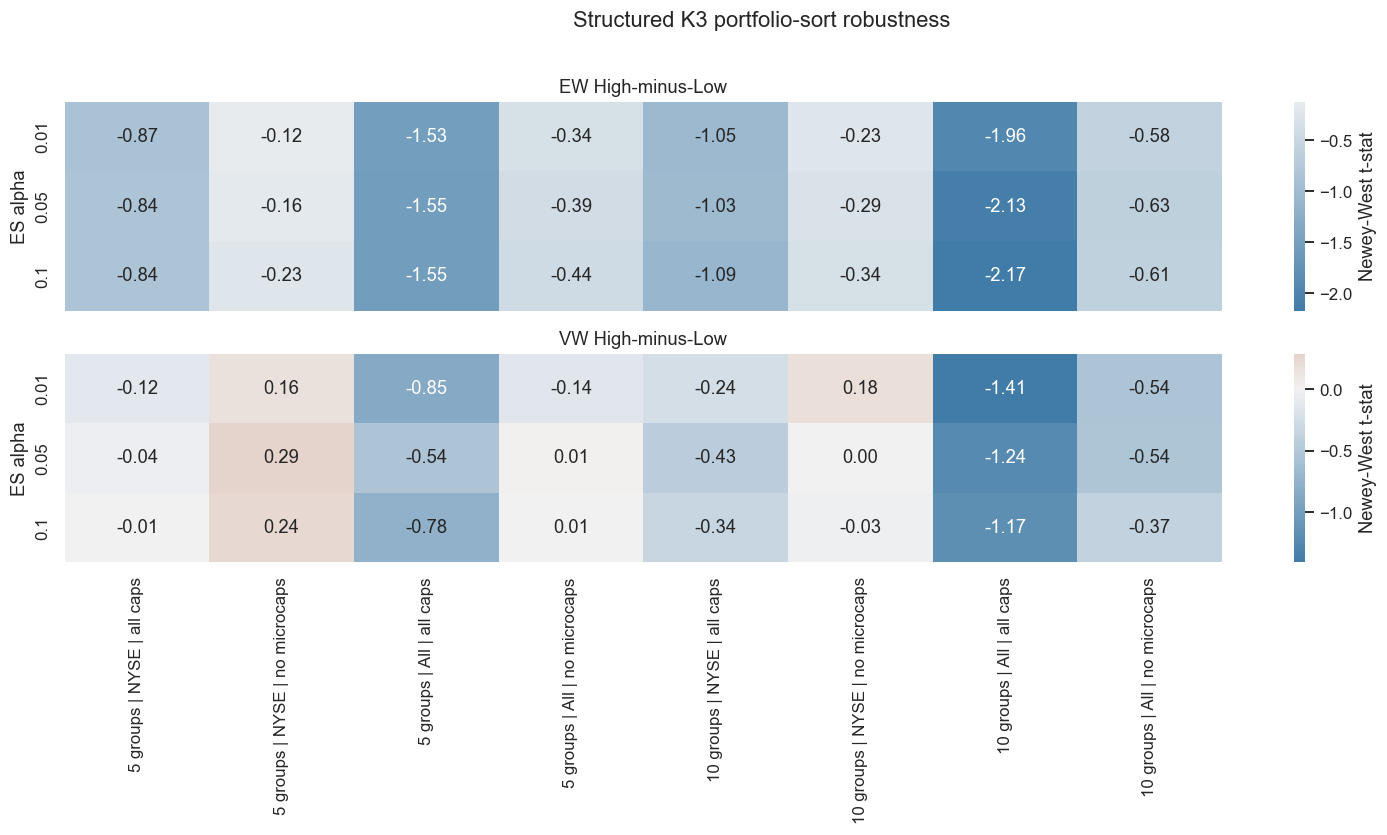

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig10_robustness_heatmap_20260831_1753.pdf')

In [29]:
# ==========================================
# 9.2 图：稳健性设计中的 H-L t-statistics
# ==========================================
design_order = [
    f"{groups} groups | {bp} | {cap}"
    for groups in [5, 10] for bp in ["NYSE", "All"] for cap in ["all caps", "no microcaps"]
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)
for ax, weighting in zip(axes, ["EW", "VW"]):
    heat = robustness_summary[robustness_summary["weighting"] == weighting].pivot(index="alpha", columns="design", values="nw_t")
    heat = heat.reindex(index=[0.01, 0.05, 0.10], columns=design_order)
    sns.heatmap(
        heat, annot=True, fmt=".2f", center=0,
        cmap=sns.diverging_palette(240, 30, as_cmap=True), cbar_kws={"label": "Newey-West t-stat"}, ax=ax,
    )
    ax.set(title=f"{weighting} High-minus-Low", xlabel="", ylabel="ES alpha")
fig.suptitle("Structured K3 portfolio-sort robustness", y=1.01)
fig.tight_layout()
save_figure(fig, "fig10_robustness_heatmap")

## 10. Adverse weight 的经济验证

这里区分两类证据：当期 VIX 和信用利差只用于解释 `pi_adverse` 的经济含义；下一月市场收益、坏市场概率和股票横截面尾部损失才是样本外状态验证。坏市场定义为样本外市场超额收益最低的 10% 月份。

作者想证明：我算出来的这个 pi_adverse（不利状态概率/权重），不仅能用来选股，它本身还是一个极其敏锐的宏观风险预测指标。

crash_share：下个月市场上跌幅超过 20% 的股票占比有多少？（全市场有多惨）。

cross_section_tail_loss：下个月跌得最惨的那 5% 的股票，平均跌了多少？（最惨的人有多惨）。

bad_market：下个月的大盘收益是不是处于历史最差的 10% 以内？（0 或 1）。

代码计算了你发明的 pi_adverse 指标与 VIX、信用利差等传统指标的相关系数 (state_macro_correlations)。


In [30]:
# ==========================================
# 10.1 构建下一月市场和横截面尾部结果
# ==========================================
macro_state = pd.read_parquet(project_root / "data/MacroFactor_McCracken.parquet", columns=["mthcaldt", "VIXCLSx", "CREDIT_SPREAD", "TERM_SPREAD"])
macro_state["mthcaldt"] = pd.to_datetime(macro_state["mthcaldt"])

realized_tail = pricing_base.groupby("mthcaldt", as_index=False).agg(
    crash_share=("target_ret_final", lambda x: np.mean(x < -0.20)),
    cross_section_tail_loss=("target_ret_final", lambda x: -x[x <= x.quantile(0.05)].mean()),
)
state_validation = state_monthly.copy()
state_validation["return_date"] = state_validation["mthcaldt"] + pd.offsets.MonthEnd(1)
state_validation = state_validation.merge(
    factor_data[["return_date", "mktrf_ff5"]], on="return_date", validate="one_to_one"
).merge(realized_tail, on="mthcaldt", validate="one_to_one").merge(
    macro_state, on="mthcaldt", how="left", validate="one_to_one"
)
state_validation["bad_market"] = (state_validation["mktrf_ff5"] <= state_validation["mktrf_ff5"].quantile(0.10)).astype(int)

macro_cols = ["VIXCLSx", "CREDIT_SPREAD", "TERM_SPREAD"]
macro_within = state_validation[["window", "pi_adverse_within_z", *macro_cols]].copy()
for column in macro_cols:
    macro_within[column] = macro_within[column] - macro_within.groupby("window")[column].transform("mean")
state_macro_correlations = macro_within[["pi_adverse_within_z", *macro_cols]].corr()
display(state_macro_correlations.loc[["pi_adverse_within_z"], macro_cols].round(3))


,VIXCLSx,CREDIT_SPREAD,TERM_SPREAD
pi_adverse_within_z,-0.05,-0.181,0.061


In [31]:
# ==========================================
# 10.2 pi_adverse 对下一月坏状态的预测回归
# ==========================================
state_outcomes = {
    "Next market excess return": "mktrf_ff5",
    "Bad-market probability": "bad_market",
    "Cross-sectional crash share": "crash_share",
    "Cross-sectional 5% tail loss": "cross_section_tail_loss",
}

rows = []
for outcome_name, outcome_col in state_outcomes.items():
    for state_spec, x_col, add_window_fe in [
        ("Global", "pi_adverse_global_z", False),
        ("Within-window + window FE", "pi_adverse_within_z", True),
    ]:
        data = state_validation[[outcome_col, x_col, "window"]].dropna().reset_index(drop=True)
        X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
        if add_window_fe:
            X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
        fit_state = sm.OLS(data[outcome_col], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
        rows.append({
            "outcome": outcome_name, "state_specification": state_spec,
            "coefficient_pi_adverse_z": fit_state.params[x_col], "nw_t": fit_state.tvalues[x_col],
            "p_value": fit_state.pvalues[x_col], "months": int(fit_state.nobs),
        })
state_validation_regressions = pd.DataFrame(rows)
display(state_validation_regressions.round(5))


,outcome,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,Next market excess return,Global,-0.00228,-0.75653,0.44933,216
1,Next market excess return,Within-window + window FE,-0.00254,-0.61608,0.53784,216
2,Bad-market probability,Global,0.01630,0.78505,0.43242,216
3,Bad-market probability,Within-window + window FE,0.00867,0.32547,0.74483,216
4,Cross-sectional crash share,Global,0.00527,1.23656,0.21625,216
5,Cross-sectional crash share,Within-window + window FE,0.00574,0.97012,0.33198,216
6,Cross-sectional 5% tail loss,Global,0.00717,1.03650,0.29997,216
7,Cross-sectional 5% tail loss,Within-window + window FE,0.00300,0.58780,0.55666,216


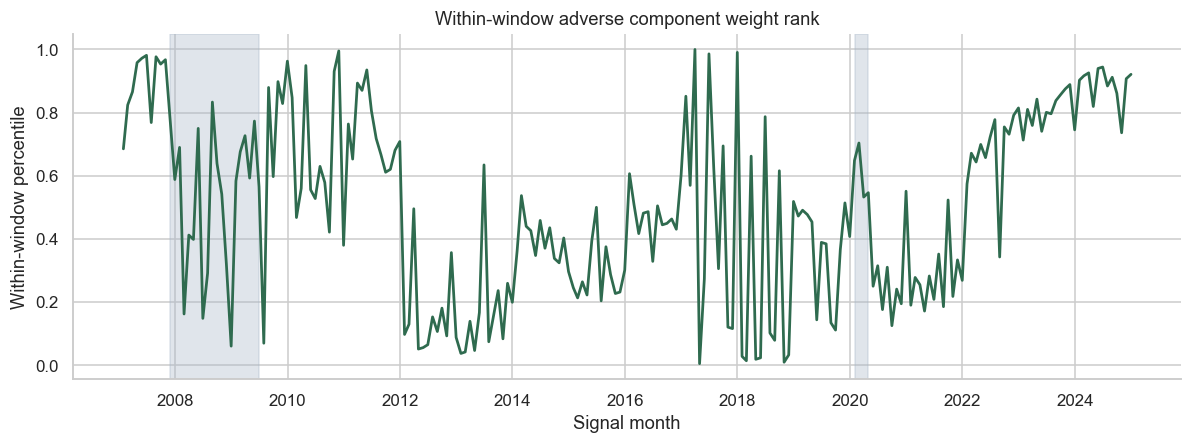

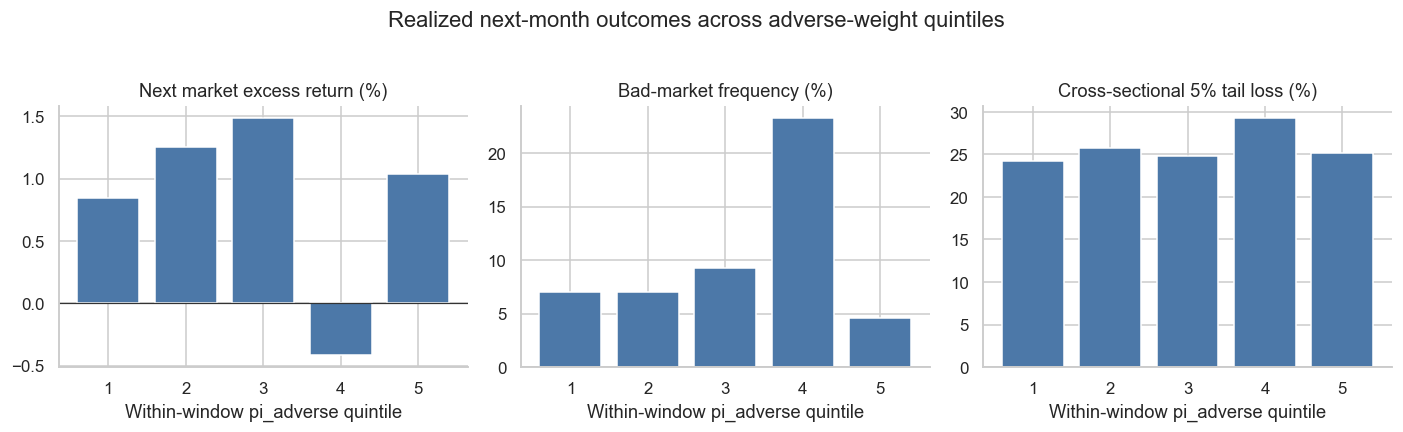

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig12_adverse_weight_validation_20260831_1753.pdf')

In [32]:
# ==========================================
# 10.3 图：窗口内 adverse-weight rank 和下一月结果
# ==========================================
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(state_validation["mthcaldt"], state_validation["pi_rank_global"], color="#2F6B4F", linewidth=1.8)
for start, end in [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#A7B7C7", alpha=0.35)
ax.set(title="Within-window adverse component weight rank", xlabel="Signal month", ylabel="Within-window percentile")
fig.tight_layout()
save_figure(fig, "fig11_adverse_weight_time_series")

state_validation["pi_rank_global"] = pd.cut(state_validation["pi_rank_global"], np.linspace(0, 1, 6), labels=np.arange(1, 6), include_lowest=True)
state_bins = state_validation.groupby("pi_rank_global", observed=True).agg(
    market_return=("mktrf_ff5", "mean"), bad_market_rate=("bad_market", "mean"),
    tail_loss=("cross_section_tail_loss", "mean"), months=("mthcaldt", "size"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (column, title) in zip(axes, [
    ("market_return", "Next market excess return (%)"),
    ("bad_market_rate", "Bad-market frequency (%)"),
    ("tail_loss", "Cross-sectional 5% tail loss (%)"),
]):
    ax.bar(state_bins["pi_rank_global"].astype(int), 100 * state_bins[column], color="#4C78A8", edgecolor="white")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=title, xlabel="Within-window pi_adverse quintile", xticks=np.arange(1, 6))
fig.suptitle("Realized next-month outcomes across adverse-weight quintiles", y=1.03)
fig.tight_layout()
save_figure(fig, "fig12_adverse_weight_validation")


## 11. Severity 是否超越普通波动率

每个月先用 `sigma_bench`、规模、账面市值比和动量解释 adverse severity，再使用剩余部分进行组合排序和 Fama–MacBeth。该检验直接回答 severity 是否只是一个复杂的波动率信号。就是看残差是否显著


In [33]:
# ==========================================
# 11.1 构造横截面 residual severity
# ==========================================
def residualize_monthly(panel, dependent, controls, output_col):
    required = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse", dependent, *controls]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    work = standardize_monthly(work, [dependent, *controls])
    work[output_col] = np.nan
    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        X = sm.add_constant(month[[f"z_{c}" for c in controls]].to_numpy(dtype=float))
        y = month[f"z_{dependent}"].to_numpy(dtype=float)
        work.loc[positions, output_col] = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    return work


residual_severity_panel = residualize_monthly(
    pricing_base, "severity_adverse_5", control_cols, "severity_residual"
)
residual_severity_slopes = run_fama_macbeth(
    residual_severity_panel, "severity_residual", "residual_adverse_severity",
    "Residual adverse severity", "Residual adverse severity",
)
residual_severity_fmb = summarize_fama_macbeth(residual_severity_slopes)

residual_severity_portfolios = sort_portfolios(residual_severity_panel, "severity_residual", PRIMARY_GROUPS, me_breakpoints, False, breakpoint_universe="NYSE")
residual_metadata = {
    "model_id": "residual_adverse_severity", "model_label": "Residual adverse severity",
    "signal_name": "Residual adverse severity", "n_groups": PRIMARY_GROUPS,
    "exclude_microcaps": False, "breakpoint_universe": "NYSE",
}
residual_severity_hml = build_hml(residual_severity_portfolios, residual_metadata)
residual_severity_hml_summary = summarize_hml(residual_severity_hml)
display(residual_severity_fmb[residual_severity_fmb["specification"] == "Controls"][[
    "signal_name", "annualized_slope_pct", "nw_t", "p_value"
]].round(4))
display(residual_severity_hml_summary[["weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))


,signal_name,annualized_slope_pct,nw_t,p_value
0,Residual adverse severity,-2.5552,-1.5799,0.1141


,weighting,annualized_mean_pct,nw_t,p_value
0,EW,-7.7516,-1.5712,0.1161
1,VW,5.9464,0.8977,0.3693


## 12. State-dependent pricing horse race

使用同一个 Structured `pi_adverse` 分别解释五个模型总 ES、adverse contribution、raw severity 和 residual severity 的月度价格斜率。若简单模型也得到相同结果，经济事实仍成立，但 Structured decomposition 不是必要条件。


逻辑： 正如中文注释所说：“若简单模型也得到相同结果……Structured decomposition 就不是必要条件。”所以这里引入了一个简单的基准模型叫 linear_quantile。

做法：

代码首先计算了“复杂模型斜率”与“简单模型斜率”的差值（difference = wide[candidate] - wide["linear_quantile"]）。

然后用市场状态 pi_adverse 去回归这个差值。

结论如何看： 如果回归结果显著（p_value 很小，nw_t 绝对值很大），说明复杂模型对恶劣市场状态的敏感度显著区别于（且通常是优于）简单的线性模型。这就证明了研究者费尽心思搞出来的“结构化分解”是不可替代的，是有学术价值的。

In [34]:
# ==========================================
# 12.1 月度 signal price 对 adverse weight 的回归
# ==========================================
def state_price_regression(slopes, state):
    #回归公式: signal_slope = β0 + β1 * adverse_weight + ε
    rows = []
    group_cols = ["model_id", "model_label", "signal_name"]
    for keys, group in slopes[slopes["specification"] == "Controls"].groupby(group_cols):
        data = group.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_spec, x_col, add_window_fe in [
            ("Global", "pi_adverse_global_z", False),
            ("Within-window + window FE", "pi_adverse_within_z", True),
        ]:
            X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
            if add_window_fe:
                X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit_price = sm.OLS(data["signal_slope"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            ci = fit_price.conf_int().loc[x_col]
            rows.append({
                **dict(zip(group_cols, keys)), "state_specification": state_spec,
                "coefficient": fit_price.params[x_col], "nw_t": fit_price.tvalues[x_col], "p_value": fit_price.pvalues[x_col],
                "ci_95_low": ci.iloc[0], "ci_95_high": ci.iloc[1], "months": int(fit_price.nobs),
            })
    return pd.DataFrame(rows)


def compare_state_price_to_linear(slopes, state):
    # 回归公式: slope_difference = β0 + β1 * adverse_weight + ε
    controls = slopes[slopes["specification"] == "Controls"]
    wide = controls.pivot(index="mthcaldt", columns="model_id", values="signal_slope")
    candidates = ["structured_normal_k3", "structured_adverse_contribution", "structured_adverse_severity", "residual_adverse_severity"]
    labels = controls.drop_duplicates("model_id").set_index("model_id")["model_label"].to_dict()
    rows = []
    for candidate in candidates:
        difference = (wide[candidate] - wide["linear_quantile"]).rename("slope_difference").reset_index()
        data = difference.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_spec, x_col, add_window_fe in [
            ("Global", "pi_adverse_global_z", False),
            ("Within-window + window FE", "pi_adverse_within_z", True),
        ]:
            X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
            if add_window_fe:
                X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit_diff = sm.OLS(data["slope_difference"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            rows.append({
                "model_id": candidate, "model_label": labels[candidate], "benchmark": "Linear Quantile",
                "state_specification": state_spec, "difference_coefficient": fit_diff.params[x_col],
                "nw_t": fit_diff.tvalues[x_col], "p_value": fit_diff.pvalues[x_col], "months": int(fit_diff.nobs),
            })
    return pd.DataFrame(rows)


horse_race_slopes = pd.concat([fmb_monthly_slopes, residual_severity_slopes], ignore_index=True)
state_price_horse_race = state_price_regression(horse_race_slopes, state_monthly)
state_price_vs_linear = compare_state_price_to_linear(horse_race_slopes, state_monthly)
display(state_price_horse_race[["model_label", "state_specification", "coefficient", "nw_t", "p_value"]].round(5))
display(state_price_vs_linear.round(5))


,model_label,state_specification,coefficient,nw_t,p_value
0,Fused Normal K1,Global,-0.00012,-0.11070,0.91186
1,Fused Normal K1,Within-window + window FE,-0.00102,-0.90056,0.36782
2,Fused Normal K3,Global,0.00012,0.10367,0.91743
3,Fused Normal K3,Within-window + window FE,-0.00139,-1.35034,0.17691
4,Linear Quantile,Global,-0.00062,-0.56250,0.57377
5,Linear Quantile,Within-window + window FE,-0.00107,-0.90463,0.36566
6,Residual adverse severity,Global,0.00015,0.14838,0.88205
7,Residual adverse severity,Within-window + window FE,-0.00075,-0.75963,0.44748
8,Rolling Normal,Global,0.00070,0.82506,0.40934
9,Rolling Normal,Within-window + window FE,-0.00034,-0.38138,0.70292


,model_id,model_label,benchmark,state_specification,difference_coefficient,nw_t,p_value,months
0,structured_normal_k3,Structured Normal K3,Linear Quantile,Global,0.00122,3.74810,0.00018,216
1,structured_normal_k3,Structured Normal K3,Linear Quantile,Within-window + window FE,0.00055,1.60613,0.10825,216
2,structured_adverse_contribution,Adverse contribution,Linear Quantile,Global,-0.00126,-1.38953,0.16467,216
3,structured_adverse_contribution,Adverse contribution,Linear Quantile,Within-window + window FE,-0.00081,-1.02429,0.30570,216
4,structured_adverse_severity,Adverse severity,Linear Quantile,Global,0.00085,2.74319,0.00608,216
5,structured_adverse_severity,Adverse severity,Linear Quantile,Within-window + window FE,0.00026,0.70720,0.47944,216
6,residual_adverse_severity,Residual adverse severity,Linear Quantile,Global,0.00077,2.49425,0.01262,216
7,residual_adverse_severity,Residual adverse severity,Linear Quantile,Within-window + window FE,0.00032,0.82306,0.41047,216


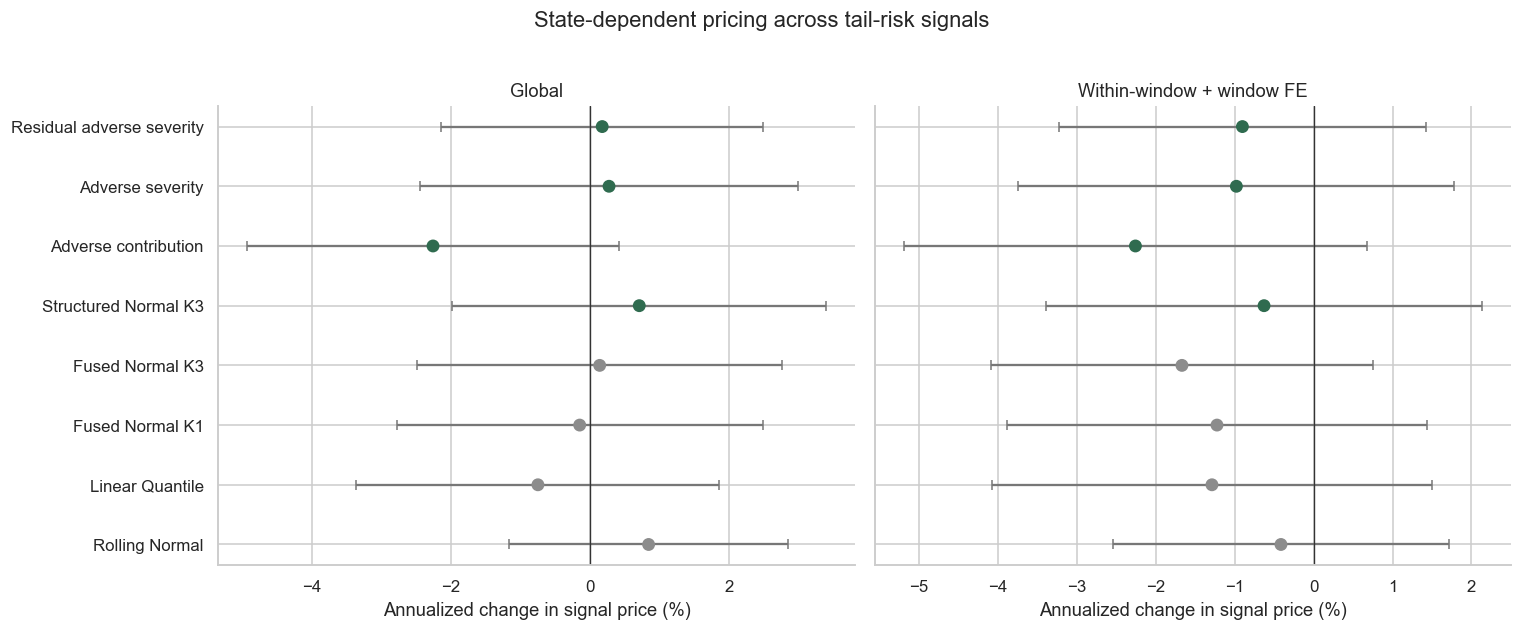

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig13_state_price_horse_race_20260831_1753.pdf')

In [35]:
# ==========================================
# 12.2 图：不同 tail signals 的状态依赖价格
# ==========================================
horse_order = [*model_labels.values(), "Adverse contribution", "Adverse severity", "Residual adverse severity"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)
for ax, state_spec in zip(axes, ["Global", "Within-window + window FE"]):
    plot_data = state_price_horse_race[state_price_horse_race["state_specification"] == state_spec].set_index("model_label").reindex(horse_order).dropna().reset_index()
    plot_data["estimate"] = 1200 * plot_data["coefficient"]
    plot_data["low"], plot_data["high"] = 1200 * plot_data["ci_95_low"], 1200 * plot_data["ci_95_high"]
    y = np.arange(len(plot_data))
    colors = ["#2F6B4F" if ("Adverse" in label or "Residual" in label or label == "Structured Normal K3") else "#8C8C8C" for label in plot_data["model_label"]]
    ax.errorbar(plot_data["estimate"], y, xerr=[plot_data["estimate"] - plot_data["low"], plot_data["high"] - plot_data["estimate"]], fmt="none", ecolor="#777777", capsize=3)
    ax.scatter(plot_data["estimate"], y, c=colors, s=55, zorder=3)
    ax.axvline(0, color="#333333", linewidth=0.9)
    ax.set(title=state_spec, xlabel="Annualized change in signal price (%)", yticks=y, yticklabels=plot_data["model_label"])
    ax.invert_yaxis()
fig.suptitle("State-dependent pricing across tail-risk signals", y=1.02)
fig.tight_layout()
save_figure(fig, "fig13_state_price_horse_race")


In [37]:
diagnostic_panel

,permno,mthcaldt,return_date,target_ret_final,mthcap,mthcap_log,bm,is_nyse,es_5,portfolio,z_mthcap_log,z_bm
0,10001,2007-01-31,2007-02-28,0.264774,3.360951e+04,10.422564,0.782398,False,0.180256,3,-1.866714,0.965110
1,10025,2007-01-31,2007-02-28,-0.028094,3.700557e+05,12.821409,0.143568,False,0.341703,8,-0.442496,-1.153736
2,10026,2007-01-31,2007-02-28,-0.038517,7.653725e+05,13.548118,0.489391,False,0.168215,3,-0.011042,-0.006724
3,10032,2007-01-31,2007-02-28,-0.023810,7.772520e+05,13.563520,0.542692,False,0.541191,10,-0.001897,0.170064
4,10044,2007-01-31,2007-02-28,0.021561,8.212570e+04,11.316006,0.165279,False,0.219821,5,-1.336268,-1.081725
...,...,...,...,...,...,...,...,...,...,...,...,...
480424,93372,2024-12-31,2025-01-31,0.093948,5.457112e+05,13.209845,0.449300,True,0.216612,8,-0.767640,-0.114106
480425,93397,2024-12-31,2025-01-31,-0.057236,4.423102e+05,12.999767,0.435276,False,0.184750,5,-0.874095,-0.145502
480426,93426,2024-12-31,2025-01-31,-0.007243,2.867095e+05,12.566225,0.974849,True,0.217655,8,-1.093787,1.062458
480427,93434,2024-12-31,2025-01-31,0.147685,1.709061e+04,9.746284,3.796202,False,0.425872,10,-2.316306,4.158234


## 13. 极端 ES 组合的公司特征

下面检查第 10 组收益骤降是否同时伴随更小规模、更高波动率、更高账面市值比或更差动量。所有特征先在月内 winsorize 并标准化，再对月份等权平均。


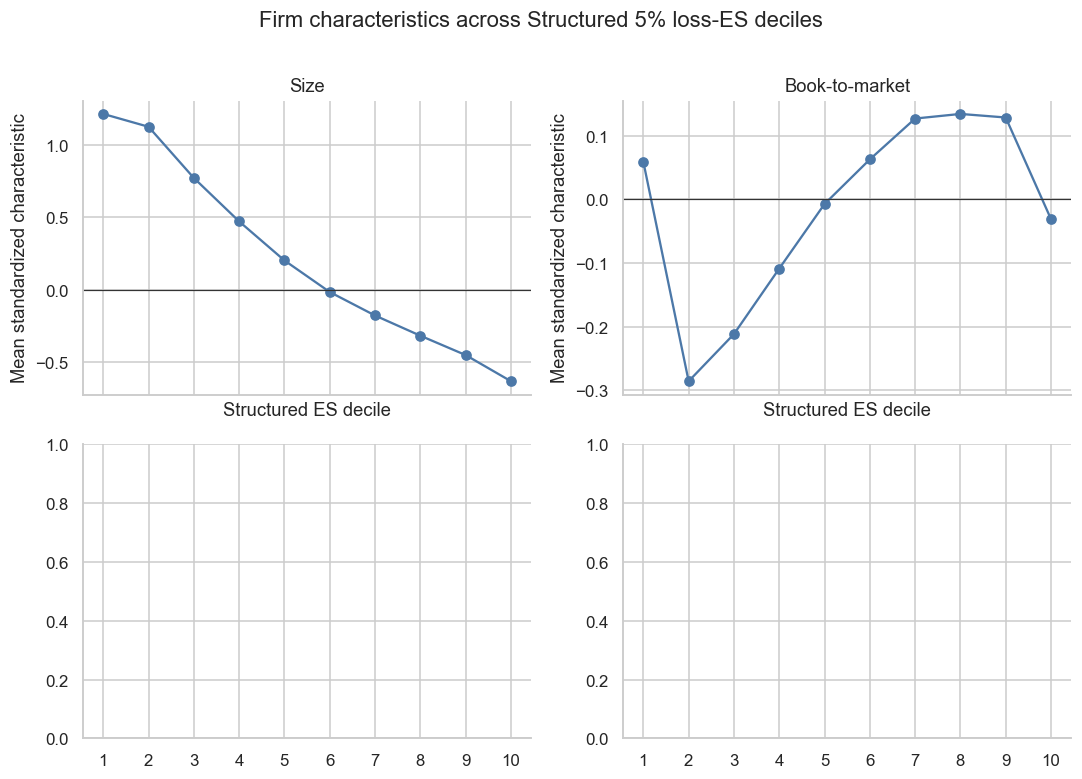

,portfolio,Size,Book-to-market
0,1,1.213,0.059
1,2,1.124,-0.286
2,3,0.771,-0.211
3,4,0.472,-0.109
4,5,0.203,-0.007
5,6,-0.015,0.063
6,7,-0.177,0.127
7,8,-0.316,0.134
8,9,-0.450,0.129
9,10,-0.630,-0.031


In [38]:
# ==========================================
# 13.1 Structured ES deciles 的特征轮廓
# ==========================================
# def assign_nyse_groups(panel, signal_col, n_groups=10):
#     work = panel.copy().reset_index(drop=True)
#     groups = np.empty(len(work), dtype=np.int8)
#     for positions in work.groupby("mthcaldt", sort=False).indices.values():
#         month = work.iloc[positions]
#         breaks = np.quantile(month.loc[:, signal_col], np.arange(1, n_groups) / n_groups)
#         groups[positions] = np.searchsorted(breaks, month[signal_col].to_numpy(), side="right") + 1
#     work["portfolio"] = groups
#     return work


# diagnostic_panel = standardize_monthly(
#     assign_nyse_groups(pricing_base, "es_5", PRIMARY_GROUPS), control_cols
# )

diagnostic_panel = assign_signal_groups(
    panel=pricing_base,
    signal_col="es_5",
    n_groups=PRIMARY_GROUPS,
    breakpoint_universe="NYSE",
    me_breakpoints_df=me_breakpoints,
    exclude_microcaps=False,
)

diagnostic_panel = standardize_monthly(
    diagnostic_panel,
    control_cols,
)


# diagnostic_cols = {"mthcap_log": "Size", "sigma_bench": "Volatility", "bm": "Book-to-market", "MOM12m": "Momentum"}
diagnostic_cols = {"mthcap_log": "Size","bm": "Book-to-market",}
decile_characteristics = diagnostic_panel.groupby(["mthcaldt", "portfolio"], as_index=False).agg(
    **{label: (f"z_{column}", "mean") for column, label in diagnostic_cols.items()}
).groupby("portfolio", as_index=False).mean(numeric_only=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for ax, label in zip(axes.flat, diagnostic_cols.values()):
    ax.plot(decile_characteristics["portfolio"], decile_characteristics[label], marker="o", color="#4C78A8")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=label, xlabel="Structured ES decile", ylabel="Mean standardized characteristic", xticks=np.arange(1, 11))
fig.suptitle("Firm characteristics across Structured 5% loss-ES deciles", y=1.01)
fig.tight_layout()
save_figure(fig, "fig14_es_decile_characteristics")
display(decile_characteristics.round(3))


## 14. 外部可观测坏状态

模型自己的 $\pi_{adverse}$ 没有可靠地预测下一期市场坏状态，因此本节不再用它定义宏观状态。主检验改用预测时点 $t$ 已知的三个外部指标：VIX、信用利差和过去 12 个月市场峰值回撤。

先分别标准化三个指标，再等权平均并重新标准化：

$$
Stress_t=Z\left[\frac{Z(VIX_t)+Z(CreditSpread_t)+Z(Drawdown_t)}{3}\right].
$$

`Stress` 越高表示当期金融环境越差。全样本标准化只改变回归系数的单位，不用于预测未来信息；三个单项指标作为分项结果，等权综合指标是预先确定的主检验。

In [39]:
# ==========================================
# 14.1 构造预测时点已知的外部金融压力指数
# ==========================================

with sqlite3.connect(WRDS_db_path) as conn:
    market_index = pd.read_sql_query("SELECT date, sprtrn FROM crsp_msi ORDER BY date", conn)

market_index["mthcaldt"] = pd.to_datetime(market_index["date"]) + pd.offsets.MonthEnd(0)
market_index["market_wealth"] = (1 + market_index["sprtrn"].fillna(0)).cumprod()
market_index["market_peak_12m"] = market_index["market_wealth"].rolling(12, min_periods=1).max()
market_index["market_drawdown_12m"] = 1 - market_index["market_wealth"] / market_index["market_peak_12m"]

external_state_monthly = (
    state_monthly[["mthcaldt", "window"]]
    .merge(macro_state[["mthcaldt", "VIXCLSx", "CREDIT_SPREAD"]], on="mthcaldt", validate="one_to_one")
    .merge(market_index[["mthcaldt", "market_drawdown_12m"]], on="mthcaldt", validate="one_to_one")
)

external_components = {
    "VIX": ("VIXCLSx", "vix_z"),
    "Credit spread": ("CREDIT_SPREAD", "credit_spread_z"),
    "Market drawdown": ("market_drawdown_12m", "market_drawdown_z"),
}
for _, (source, output) in external_components.items():
    external_state_monthly[output] = (external_state_monthly[source] - external_state_monthly[source].mean()) / external_state_monthly[source].std(ddof=1)

component_z = [output for _, output in external_components.values()]
external_state_monthly["external_stress_raw"] = external_state_monthly[component_z].mean(axis=1)
external_state_monthly["external_stress_z"] = (external_state_monthly["external_stress_raw"] - external_state_monthly["external_stress_raw"].mean()) / external_state_monthly["external_stress_raw"].std(ddof=1)
external_state_monthly["external_stress_rank"] = external_state_monthly["external_stress_z"].rank(pct=True)
external_state_monthly["stress_group"] = np.select(
    [external_state_monthly["external_stress_rank"] <= 1 / 3, external_state_monthly["external_stress_rank"] >= 2 / 3],
    ["Low stress", "High stress"], default="Middle",
)

display(external_state_monthly.head().round(3))

,mthcaldt,window,VIXCLSx,CREDIT_SPREAD,market_drawdown_12m,vix_z,credit_spread_z,market_drawdown_z,external_stress_raw,external_stress_z,external_stress_rank,stress_group
0,2007-01-31,0,NaN,1.66,0.000,NaN,-1.126,-0.579,-0.852,-0.959,0.037,Low stress
1,2007-02-28,0,NaN,1.58,0.022,NaN,-1.228,-0.328,-0.778,-0.877,0.074,Low stress
2,2007-03-31,0,NaN,1.56,0.012,NaN,-1.253,-0.440,-0.847,-0.953,0.046,Low stress
3,2007-04-30,0,NaN,1.71,0.000,NaN,-1.062,-0.579,-0.821,-0.924,0.060,Low stress
4,2007-05-31,0,NaN,1.70,0.000,NaN,-1.075,-0.579,-0.827,-0.931,0.051,Low stress


In [40]:
# ==========================================
# 14.2 月度风险价格是否随外部坏状态上升
# ==========================================
# 回归方程是: signal_slope = β0 + β1 * external_state + controls + ε
external_state_specs = {
    "External stress composite": "external_stress_z",
    "VIX": "vix_z",
    "Credit spread": "credit_spread_z",
    "Market drawdown": "market_drawdown_z",
}


def regress_prices_on_external_state(slopes, state, state_specs=external_state_specs):
    rows = []
    controls = slopes[slopes["specification"] == "Controls"]
    for keys, group in controls.groupby(["model_id", "model_label", "signal_name"]):
        data = group.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_name, state_col in state_specs.items():
            X = pd.DataFrame({"const": 1.0, state_col: data[state_col]})
            X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit = sm.OLS(data["signal_slope"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            ci = fit.conf_int().loc[state_col]
            rows.append({
                "model_id": keys[0], "model_label": keys[1], "signal_name": keys[2], "state_variable": state_name,
                "coefficient": fit.params[state_col], "nw_t": fit.tvalues[state_col], "p_value": fit.pvalues[state_col],
                "ci_95_low": ci.iloc[0], "ci_95_high": ci.iloc[1], "months": int(fit.nobs),
            })
    return pd.DataFrame(rows)


def compare_external_price_to_linear(slopes, state, state_specs=external_state_specs):
    controls = slopes[slopes["specification"] == "Controls"]
    wide = controls.pivot(index="mthcaldt", columns="model_id", values="signal_slope")
    labels = controls.drop_duplicates("model_id").set_index("model_id")["model_label"].to_dict()
    candidates = ["structured_normal_k3", "structured_adverse_contribution", "structured_adverse_severity", "residual_adverse_severity"]
    rows = []
    for candidate in candidates:
        difference = (wide[candidate] - wide["linear_quantile"]).rename("slope_difference").reset_index()
        data = difference.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_name, state_col in state_specs.items():
            X = pd.DataFrame({"const": 1.0, state_col: data[state_col]})
            X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit = sm.OLS(data["slope_difference"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            rows.append({
                "model_id": candidate, "model_label": labels[candidate], "benchmark": "Linear Quantile",
                "state_variable": state_name, "difference_coefficient": fit.params[state_col],
                "nw_t": fit.tvalues[state_col], "p_value": fit.pvalues[state_col], "months": int(fit.nobs),
            })
    return pd.DataFrame(rows)


external_state_price = regress_prices_on_external_state(horse_race_slopes, external_state_monthly)
external_state_vs_linear = compare_external_price_to_linear(horse_race_slopes, external_state_monthly)

display(external_state_price[external_state_price["state_variable"] == "External stress composite"][["model_label", "coefficient", "nw_t", "p_value"]].round(5))
display(external_state_vs_linear[external_state_vs_linear["state_variable"] == "External stress composite"].round(5))

,model_label,coefficient,nw_t,p_value
0,Fused Normal K1,0.00568,0.88072,0.37847
4,Fused Normal K3,0.00983,1.39398,0.16332
8,Linear Quantile,0.00121,0.22111,0.82501
12,Residual adverse severity,0.00278,0.53698,0.59128
16,Rolling Normal,0.00344,0.64520,0.51880
20,Adverse contribution,0.00303,0.49168,0.62295
24,Adverse severity,0.00389,0.62645,0.53102
28,Structured Normal K3,0.00439,0.71295,0.47588


,model_id,model_label,benchmark,state_variable,difference_coefficient,nw_t,p_value,months
0,structured_normal_k3,Structured Normal K3,Linear Quantile,External stress composite,0.00318,1.13915,0.25464,37
4,structured_adverse_contribution,Adverse contribution,Linear Quantile,External stress composite,0.00182,0.66543,0.50577,37
8,structured_adverse_severity,Adverse severity,Linear Quantile,External stress composite,0.00268,0.98838,0.32297,37
12,residual_adverse_severity,Residual adverse severity,Linear Quantile,External stress composite,0.00157,0.65714,0.51109,37


In [41]:
# ==========================================
# 14.3 个股层 pooled interaction 与高低压力状态组合
# ==========================================
# 回归方程是: return_demeaned = β0 + β1 * z_signal + β2 * (z_signal * external_state) + controls + ε
def pooled_external_interaction(panel, signal_col, signal_name, state_col="external_stress_z"):
    required = ["mthcaldt", "target_ret_final", signal_col, *control_cols]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work = standardize_monthly(work, [signal_col, *control_cols])
    work = work.merge(external_state_monthly[["mthcaldt", state_col]], on="mthcaldt", validate="many_to_one")
    work["interaction"] = work[f"z_{signal_col}"] * work[state_col]
    work["return_demeaned"] = work["target_ret_final"] - work.groupby("mthcaldt")["target_ret_final"].transform("mean")
    regressors = [f"z_{signal_col}", "interaction", *[f"z_{column}" for column in control_cols]]
    fit = sm.OLS(work["return_demeaned"], work[regressors]).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(work["mthcaldt"])[0]}
    )
    return {
        "signal_name": signal_name, "coefficient": fit.params["interaction"], "cluster_t": fit.tvalues["interaction"],
        "p_value": fit.pvalues["interaction"], "observations": int(fit.nobs), "months": work["mthcaldt"].nunique(),
    }


linear_panel = load_model_panel("linear_quantile")
external_pooled_interactions = pd.DataFrame([
    pooled_external_interaction(pricing_base, "es_5", "Structured total ES"),
    pooled_external_interaction(pricing_base, "es_contribution_adverse_5", "Adverse contribution"),
    pooled_external_interaction(pricing_base, "severity_adverse_5", "Adverse severity"),
    pooled_external_interaction(residual_severity_panel, "severity_residual", "Residual adverse severity"),
    pooled_external_interaction(linear_panel, "signal", "Linear Quantile ES"),
])


def external_hml_state_test(hml, state):
    data = hml.merge(state[["mthcaldt", "stress_group"]], on="mthcaldt", validate="many_to_one")
    data = data[data["stress_group"].isin(["Low stress", "High stress"])].copy()
    data["high_stress"] = (data["stress_group"] == "High stress").astype(int)
    rows = []
    for keys, group in data.groupby(["model_id", "model_label", "signal_name", "weighting"]):
        fit = sm.OLS(group["hml_return"], sm.add_constant(group["high_stress"])).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
        rows.append({
            **dict(zip(["model_id", "model_label", "signal_name", "weighting"], keys)),
            "low_stress_mean": fit.params["const"], "high_minus_low_stress": fit.params["high_stress"],
            "difference_t": fit.tvalues["high_stress"], "difference_p": fit.pvalues["high_stress"], "months": int(fit.nobs),
        })
    return pd.DataFrame(rows)


all_signal_hml = pd.concat([primary_hml, mechanism_hml, residual_severity_hml], ignore_index=True)
external_state_hml = external_hml_state_test(all_signal_hml, external_state_monthly)
display(external_pooled_interactions.round(5))
display(external_state_hml[(external_state_hml["weighting"] == "EW") & external_state_hml["signal_name"].isin(["Adverse contribution", "Adverse severity", "Residual adverse severity"])].round(5))

,signal_name,coefficient,cluster_t,p_value,observations,months
0,Structured total ES,0.00369,2.10919,0.03493,459489,216
1,Adverse contribution,0.00337,1.83267,0.06685,459489,216
2,Adverse severity,0.00377,2.12545,0.03355,459489,216
3,Residual adverse severity,0.00327,1.99810,0.04571,456733,216
4,Linear Quantile ES,0.00364,2.34618,0.01897,459489,216


,model_id,model_label,signal_name,weighting,low_stress_mean,high_minus_low_stress,difference_t,difference_p,months
6,residual_adverse_severity,Residual adverse severity,Residual adverse severity,EW,-0.01264,0.01095,1.09405,0.27393,145
10,structured_adverse_contribution,Adverse contribution,Adverse contribution,EW,-0.00536,0.01283,1.13919,0.25462,145
12,structured_adverse_severity,Adverse severity,Adverse severity,EW,-0.01411,0.01390,1.11015,0.26693,145


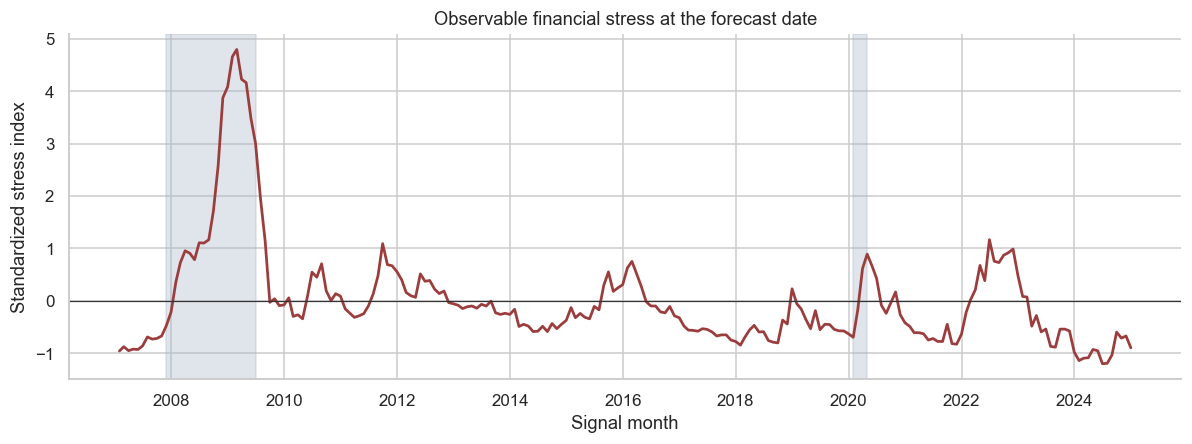

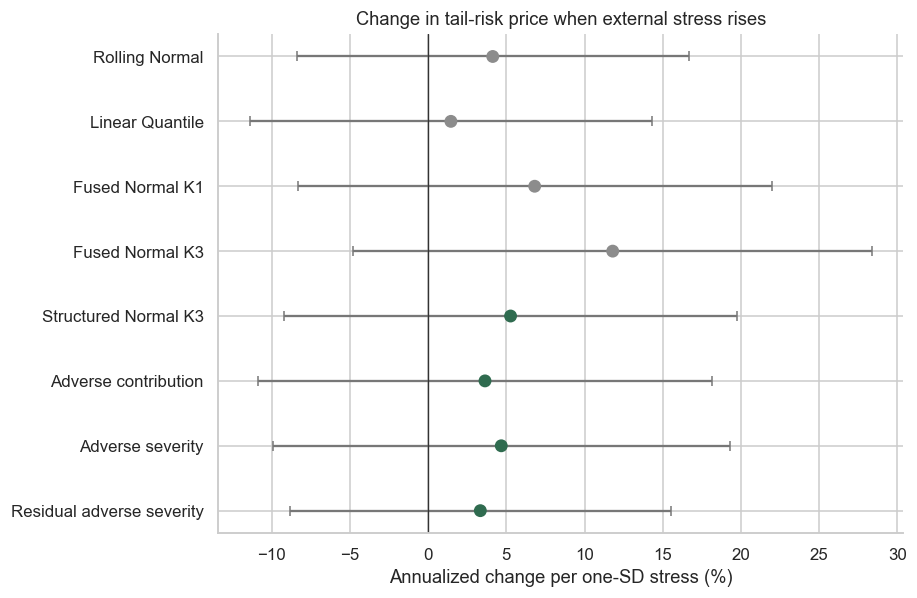

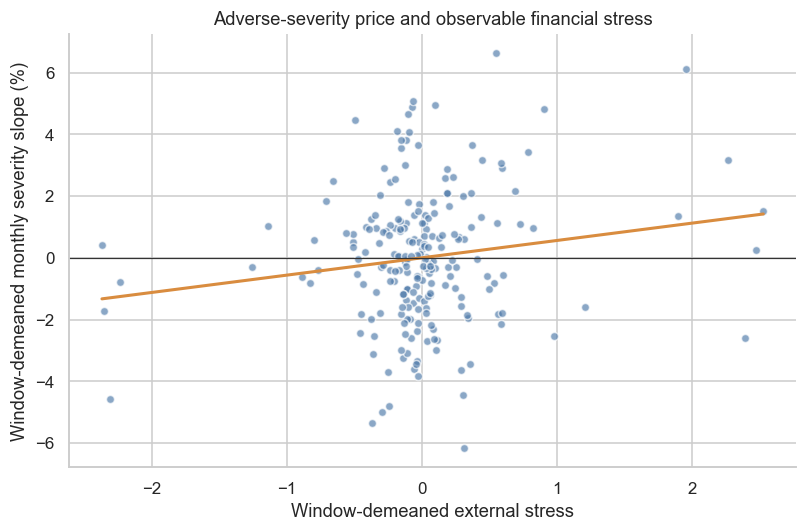

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig17_external_stress_severity_scatter_20260831_1753.pdf')

In [42]:
# ==========================================
# 14.4 外部坏状态图
# ==========================================
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(external_state_monthly["mthcaldt"], external_state_monthly["external_stress_z"], color="#9C3D3D", linewidth=1.8)
for start, end in [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#A7B7C7", alpha=0.35)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set(title="Observable financial stress at the forecast date", xlabel="Signal month", ylabel="Standardized stress index")
fig.tight_layout()
save_figure(fig, "fig15_external_stress_time_series")

horse_order = [*model_labels.values(), "Adverse contribution", "Adverse severity", "Residual adverse severity"]
plot_data = external_state_price[external_state_price["state_variable"] == "External stress composite"].set_index("model_label").reindex(horse_order).dropna().reset_index()
plot_data["estimate"], plot_data["low"], plot_data["high"] = 1200 * plot_data["coefficient"], 1200 * plot_data["ci_95_low"], 1200 * plot_data["ci_95_high"]
fig, ax = plt.subplots(figsize=(8.5, 5.6))
y = np.arange(len(plot_data))
colors = ["#2F6B4F" if ("Adverse" in label or "Residual" in label or label == "Structured Normal K3") else "#8C8C8C" for label in plot_data["model_label"]]
ax.errorbar(plot_data["estimate"], y, xerr=[plot_data["estimate"] - plot_data["low"], plot_data["high"] - plot_data["estimate"]], fmt="none", ecolor="#777777", capsize=3)
ax.scatter(plot_data["estimate"], y, c=colors, s=55, zorder=3)
ax.axvline(0, color="#333333", linewidth=0.9)
ax.set(title="Change in tail-risk price when external stress rises", xlabel="Annualized change per one-SD stress (%)", yticks=y, yticklabels=plot_data["model_label"])
ax.invert_yaxis()
fig.tight_layout()
save_figure(fig, "fig16_external_state_horse_race")

severity_external = severity_slopes.merge(external_state_monthly[["mthcaldt", "window", "external_stress_z"]], on=["mthcaldt", "window"], validate="one_to_one")
severity_external["stress_within"] = severity_external["external_stress_z"] - severity_external.groupby("window")["external_stress_z"].transform("mean")
severity_external["slope_within"] = severity_external["signal_slope"] - severity_external.groupby("window")["signal_slope"].transform("mean")
fit_visual = sm.OLS(severity_external["slope_within"], sm.add_constant(severity_external["stress_within"])).fit()
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(severity_external["stress_within"], 100 * severity_external["slope_within"], s=28, alpha=0.65, color="#4C78A8", edgecolor="white")
x_line = np.linspace(severity_external["stress_within"].min(), severity_external["stress_within"].max(), 100)
ax.plot(x_line, 100 * (fit_visual.params["const"] + fit_visual.params["stress_within"] * x_line), color="#D98C3F", linewidth=2)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set(title="Adverse-severity price and observable financial stress", xlabel="Window-demeaned external stress", ylabel="Window-demeaned monthly severity slope (%)")
fig.tight_layout()
save_figure(fig, "fig17_external_stress_severity_scatter")

,outcome,min_coefficient,max_coefficient,min_t,max_p_value
0,Adverse severity,0.00525,0.00656,1.91671,0.05528
1,Severity minus Linear Quantile,0.00037,0.00127,1.28734,0.19798


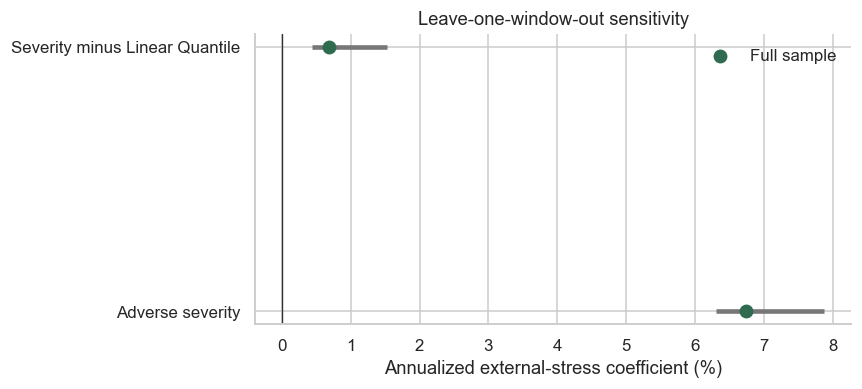

PosixPath('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/overleaf/fig/fig18_external_state_leave_one_window_out_20260831_1753.pdf')

In [43]:
# ==========================================
# 14.5 Leave-one-window-out：结果是否由单个年度窗口驱动
# ==========================================
def external_state_leave_one_window_out(slopes, state):
    controls = slopes[slopes["specification"] == "Controls"]
    wide = controls.pivot(index="mthcaldt", columns="model_id", values="signal_slope").reset_index()
    data = wide.merge(state[["mthcaldt", "window", "external_stress_z"]], on="mthcaldt", validate="one_to_one")
    outcomes = {
        "Adverse severity": data["structured_adverse_severity"],
        "Severity minus Linear Quantile": data["structured_adverse_severity"] - data["linear_quantile"],
    }
    rows = []
    for dropped_window in [None, *sorted(data["window"].unique())]:
        keep = np.ones(len(data), dtype=bool) if dropped_window is None else data["window"].ne(dropped_window).to_numpy()
        work = data.loc[keep].reset_index(drop=True)
        X = pd.DataFrame({"const": 1.0, "external_stress_z": work["external_stress_z"]})
        X = pd.concat([X, pd.get_dummies(work["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
        for outcome_name, full_y in outcomes.items():
            y = full_y.loc[keep].reset_index(drop=True)
            fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            rows.append({
                "outcome": outcome_name, "dropped_window": "Full sample" if dropped_window is None else str(dropped_window),
                "coefficient": fit.params["external_stress_z"], "nw_t": fit.tvalues["external_stress_z"],
                "p_value": fit.pvalues["external_stress_z"], "months": int(fit.nobs),
            })
    return pd.DataFrame(rows)


external_state_loo = external_state_leave_one_window_out(horse_race_slopes, external_state_monthly)
loo_exclusions = external_state_loo[external_state_loo["dropped_window"] != "Full sample"]
loo_summary = loo_exclusions.groupby("outcome", as_index=False).agg(
    min_coefficient=("coefficient", "min"), max_coefficient=("coefficient", "max"),
    min_t=("nw_t", "min"), max_p_value=("p_value", "max"),
)
display(loo_summary.round(5))

full = external_state_loo[external_state_loo["dropped_window"] == "Full sample"].set_index("outcome")
summary_plot = loo_summary.set_index("outcome").loc[["Adverse severity", "Severity minus Linear Quantile"]]
fig, ax = plt.subplots(figsize=(8, 3.7))
y = np.arange(len(summary_plot))
low, high = 1200 * summary_plot["min_coefficient"], 1200 * summary_plot["max_coefficient"]
point = 1200 * full.loc[summary_plot.index, "coefficient"]
ax.hlines(y, low, high, color="#777777", linewidth=3)
ax.scatter(point, y, color="#2F6B4F", s=65, zorder=3, label="Full sample")
ax.axvline(0, color="#333333", linewidth=0.9)
ax.set(title="Leave-one-window-out sensitivity", xlabel="Annualized external-stress coefficient (%)", yticks=y, yticklabels=summary_plot.index)
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "fig18_external_state_leave_one_window_out")


## 15. 保存结果


In [45]:
# ==========================================
# 15. 保存表格
# ==========================================
outputs = {
    "primary_portfolios": primary_portfolios,
    "primary_hml": primary_hml,
    "primary_hml_summary": primary_hml_summary,
    "structured_portfolios": structured_portfolios,
    "structured_hml": structured_hml,
    "mechanism_hml_summary": mechanism_hml_summary,
    "signal_correlation": signal_correlation.reset_index().rename(columns={"index": "variable"}),
    "factor_alphas": factor_alphas,
    "factor_coefficients": factor_coefficients,
    "fmb_monthly_slopes": fmb_monthly_slopes,
    "fmb_summary": fmb_summary,
    # "state_hml_tests": state_hml_tests,
    # "state_hml_means": state_hml_means,
    "state_slope_regression": state_slope_regression,
    "pooled_interactions": pooled_interactions,
    "robustness_hml": robustness_hml,
    "robustness_summary": robustness_summary,
    "state_validation_monthly": state_validation,
    "state_validation_regressions": state_validation_regressions,
    "state_macro_correlations": state_macro_correlations.reset_index().rename(columns={"index": "variable"}),
    "residual_severity_fmb": residual_severity_fmb,
    "residual_severity_slopes": residual_severity_slopes,
    "residual_severity_hml": residual_severity_hml,
    "residual_severity_hml_summary": residual_severity_hml_summary,
    "state_price_horse_race": state_price_horse_race,
    "state_price_vs_linear": state_price_vs_linear,
    "es_decile_characteristics": decile_characteristics,
    "external_state_monthly": external_state_monthly,
    "external_state_price": external_state_price,
    "external_state_vs_linear": external_state_vs_linear,
    "external_pooled_interactions": external_pooled_interactions,
    "external_state_hml": external_state_hml,
    "external_state_loo": external_state_loo,
    "external_state_loo_summary": loo_summary,
}

for name, frame in outputs.items():
    frame.to_parquet(result_dir / f"{name}_{model_timestamp}.parquet", index=False)

for name in ["primary_hml_summary", "mechanism_hml_summary", "factor_alphas", "fmb_summary", "state_hml_tests", "pooled_interactions", "robustness_summary", "state_validation_regressions", "residual_severity_fmb", "residual_severity_hml_summary", "state_price_horse_race", "external_state_price", "external_state_vs_linear", "external_pooled_interactions", "external_state_hml", "external_state_loo", "external_state_loo_summary"]:
    outputs[name].to_csv(result_dir / f"{name}_{model_timestamp}.csv", index=False)

print("Results saved to:", result_dir)

KeyError: 'state_hml_tests'